# 120 · Chess Siamese — Memory Bank

Este notebook parte del `110_chess_siamese.ipynb`, pero cambia la representacion del jugador:
ya no colapsamos sus partidas en un centroide medio.

La unidad de comparacion pasa a ser la **partida individual**. El embedding sigue aprendiendo una geometria
intra-player/inter-player con batch-hard triplet, pero la decision final se toma contra una memoria de
partidas conocidas por jugador. La idea es que una partida nueva quede cerca de varias partidas del mismo
jugador y lejos de las de otros jugadores, preservando subestilos, color y ritmo de decision.


In [ ]:
import io
import json
import logging
import math
import random
import re
import sqlite3
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import chess
import chess.pgn
import chess.svg
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import zstandard as zstd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score,
)
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras import Model, layers

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s"
)

SEED = 314159  # PI seed
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.style.use("seaborn-v0_8")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as gpu_err:
            logging.warning(
                "No se pudo activar memory_growth en %s: %s", gpu, gpu_err
            )
else:
    logging.warning("No se detecto GPU; el entrenamiento usara CPU.")

print(f"TensorFlow {tf.__version__}")
print("Mixed precision / XLA se configuran en la celda de entrenamiento.")


TensorFlow 2.17.0
Mixed precision / XLA se configuran en la celda de entrenamiento.


In [ ]:
def detect_repo_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "labs").exists():
            return candidate
    raise RuntimeError("No se encontro la raiz del repo (carpeta labs/).")


REPO_ROOT = detect_repo_root()
LABS_DIR = REPO_ROOT / "labs"

import sys

if str(LABS_DIR / "src") not in sys.path:
    sys.path.insert(0, str(LABS_DIR / "src"))

PGN_DATA_DIR = Path("/pgn_data")
INDEX_DB = PGN_DATA_DIR / "index.db"
PLAYERS_DIR = PGN_DATA_DIR / "players"
assert PGN_DATA_DIR.exists(), f"Volumen de datos no montado en {PGN_DATA_DIR}"
assert INDEX_DB.exists(), f"No existe {INDEX_DB}"


@dataclass
class Config:
    event_name: str = "compressed_120"

    # Dataset
    players_count: int = 10
    min_games_in_db: int = 350
    games_per_player: int = 180
    holdout_games_per_player: int = 40
    min_samples_per_player: int = 12

    # Secuencia temporal
    sequence_len: int = 15
    fullmove_start: int = 15
    fullmove_end: int = 60
    image_size: Tuple[int, int] = (192, 192)

    # Entrenamiento
    players_per_batch: int = 5
    samples_per_player: int = 4

    # Se usan como tope; el numero real de steps se ajusta dinamicamente
    # segun tamano de TRAIN/VAL para evitar epochs artificialmente largos.
    steps_per_epoch: int = 192
    val_steps: int = 48
    train_passes_per_epoch: float = 1.5
    val_passes_per_epoch: float = 0.75

    epochs: int = 2000
    min_epochs_before_es: int = 200
    early_stop_patience: int = 220
    reduce_lr_patience: int = 80
    validation_freq: int = 1

    learning_rate: float = 3e-6
    min_lr: float = 5e-8
    lr_factor: float = 0.5
    margin: float = 0.06
    ce_weight: float = 0.20
    embedding_dim: int = 256

    # Aceleracion / robustez del entrenamiento
    enable_mixed_precision: bool = True
    mixed_precision_policy: str = "mixed_float16"
    enable_xla_jit: bool = True
    resume_from_training_state: bool = True

    # Memoria de partidas por jugador
    exemplar_top_k: int = 5
    exemplar_strategy: str = "mean"  # {"mean", "softmin"}
    softmin_temperature: float = 30.0
    support_examples_per_player: int = 3

    # Rendimiento del input pipeline
    sequence_cache_size: int = 128
    sequence_cache_clear_every_n_epochs: int = 3
    fit_workers: int = 4
    fit_use_multiprocessing: bool = False
    fit_max_queue_size: int = 4

    # Split
    validation_fraction: float = 0.2

    # Otros
    seed: int = SEED


CONFIG = Config()
PLY_LABELS = [f"ply{i:02d}" for i in range(1, CONFIG.sequence_len + 1)]

OUTPUT_BASE = LABS_DIR / "notebooks" / "output" / "events" / CONFIG.event_name
TRAIN_PGN_DIR = OUTPUT_BASE / "pgn_train"
TRAIN_BOARD_DIR = OUTPUT_BASE / "board_images"
TRAIN_HEAT_DIR = OUTPUT_BASE / "heatmap_images"

HOLDOUT_PGN_DIR = OUTPUT_BASE / "pgn_holdout"
HOLDOUT_BOARD_DIR = OUTPUT_BASE / "holdout_board_images"
HOLDOUT_HEAT_DIR = OUTPUT_BASE / "holdout_heatmap_images"
PGN_TESTS_DIR = OUTPUT_BASE / "pgn_tests"

TRAINING_STATE_DIR = OUTPUT_BASE / "training_state"
CHECKPOINTS_DIR = TRAINING_STATE_DIR / "checkpoints"
BACKUP_DIR = TRAINING_STATE_DIR / "backup"
BEST_WEIGHTS_PATH = CHECKPOINTS_DIR / "metric_trainer_best.weights.h5"
LAST_WEIGHTS_PATH = CHECKPOINTS_DIR / "metric_trainer_last.weights.h5"
HISTORY_CSV_PATH = TRAINING_STATE_DIR / "history.csv"
RUN_META_PATH = TRAINING_STATE_DIR / "run_meta.json"

for p in [
    TRAIN_PGN_DIR,
    TRAIN_BOARD_DIR,
    TRAIN_HEAT_DIR,
    HOLDOUT_PGN_DIR,
    HOLDOUT_BOARD_DIR,
    HOLDOUT_HEAT_DIR,
    PGN_TESTS_DIR,
    TRAINING_STATE_DIR,
    CHECKPOINTS_DIR,
    BACKUP_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Repo raiz: {REPO_ROOT}")
print(f"Evento: {CONFIG.event_name}")
print(
    f"Secuencia: {CONFIG.sequence_len} jugadas del jugador [{CONFIG.fullmove_start}, {CONFIG.fullmove_end}]"
)
print(
    f"Memoria por jugador: top-{CONFIG.exemplar_top_k} partidas | estrategia={CONFIG.exemplar_strategy}"
)
print(
    f"Rendimiento: mixed_precision={CONFIG.enable_mixed_precision} | xla={CONFIG.enable_xla_jit} | workers={CONFIG.fit_workers}"
)


## 1) Selección de jugadores y extracción PGN (train + hold-out)


In [ ]:
def find_zst_path(player_name: str) -> Optional[Path]:
    prefix = player_name[:2].lower()
    candidate = PLAYERS_DIR / prefix / f"{player_name}.pgn.zst"
    if candidate.exists():
        return candidate

    prefix_dir = PLAYERS_DIR / prefix
    if not prefix_dir.exists():
        return None

    target = f"{player_name.lower()}.pgn.zst"
    for file_path in prefix_dir.iterdir():
        if file_path.name.lower() == target:
            return file_path
    return None


def extract_elo_from_zst(zst_path: Path, max_bytes: int = 100_000) -> Optional[int]:
    try:
        dctx = zstd.ZstdDecompressor()
        with open(zst_path, "rb") as f:
            reader = dctx.stream_reader(f)
            text = reader.read(max_bytes).decode("utf-8", errors="replace")

        values: List[int] = []
        for line in text.splitlines():
            line = line.strip()
            if line.startswith("[WhiteElo") or line.startswith("[BlackElo"):
                try:
                    elo = int(line.split('"')[1])
                except (IndexError, ValueError):
                    continue
                if 400 <= elo <= 3500:
                    values.append(elo)

        if values:
            return int(np.median(values))
    except Exception:
        return None
    return None


def select_diverse_elo_players(
    num_players: int,
    min_games: int,
    seed: int,
    candidate_pool: int = 250,
) -> pd.DataFrame:
    rng = random.Random(seed)

    conn = sqlite3.connect(str(INDEX_DB))
    try:
        df = pd.read_sql_query(
            f"SELECT name, total_games FROM players "
            f"WHERE total_games >= {min_games} "
            f"ORDER BY RANDOM() LIMIT {candidate_pool * 3}",
            conn,
        )
    finally:
        conn.close()

    records = []
    for _, row in df.iterrows():
        zst_path = find_zst_path(row["name"])
        if zst_path is None:
            continue
        elo = extract_elo_from_zst(zst_path)
        if elo is None:
            continue
        records.append(
            {
                "player": row["name"],
                "total_games": int(row["total_games"]),
                "elo": int(elo),
                "zst_path": str(zst_path),
            }
        )
        if len(records) >= candidate_pool:
            break

    cands = pd.DataFrame(records)
    if cands.empty:
        raise RuntimeError("No se encontraron candidatos válidos.")

    bins = list(range(600, 3000, 200))
    cands["elo_bin"] = pd.cut(cands["elo"], bins=bins, labels=False)

    selected_rows = []
    available_bins = sorted(cands["elo_bin"].dropna().unique())
    rng.shuffle(available_bins)

    for elo_bin in available_bins:
        if len(selected_rows) >= num_players:
            break
        group = cands[cands["elo_bin"] == elo_bin]
        picked = group.sample(1, random_state=seed).iloc[0]
        selected_rows.append(picked)

    if len(selected_rows) < num_players:
        used = {r["player"] for r in selected_rows}
        remainder = cands[~cands["player"].isin(used)]
        extra = remainder.sample(
            min(num_players - len(selected_rows), len(remainder)), random_state=seed
        )
        for _, row in extra.iterrows():
            selected_rows.append(row)

    out = pd.DataFrame(selected_rows).sort_values("elo").reset_index(drop=True)
    return out


def split_pgn_games(pgn_text: str) -> List[str]:
    games: List[str] = []
    current: List[str] = []

    for line in pgn_text.splitlines():
        if line.startswith("[Event ") and current:
            games.append("\n".join(current).strip())
            current = []
        current.append(line)

    if current:
        games.append("\n".join(current).strip())

    return [g for g in games if g]


def decompress_player_pgn_slice(
    player_name: str,
    zst_path: str,
    output_dir: Path,
    start_game_idx: int,
    max_games: int,
) -> Tuple[Path, int]:
    output_dir.mkdir(parents=True, exist_ok=True)
    out_path = output_dir / f"{player_name}.pgn"

    dctx = zstd.ZstdDecompressor()
    with open(zst_path, "rb") as f:
        reader = dctx.stream_reader(f)
        full_text = reader.read().decode("utf-8", errors="replace")

    games = split_pgn_games(full_text)
    selected = games[start_game_idx : start_game_idx + max_games]

    with open(out_path, "w", encoding="utf-8") as f:
        f.write("\n\n".join(selected))

    return out_path, len(selected)

## 2) Generación de imágenes(jugador objetivo + perspectiva normalizada)


In [ ]:
def board_to_rgb_array(board: chess.Board, size: int = 400) -> np.ndarray:
    import cairosvg

    svg = chess.svg.board(board=board, size=size, coordinates=False)
    png_bytes = cairosvg.svg2png(bytestring=svg.encode("utf-8"))
    png_array = np.frombuffer(png_bytes, dtype=np.uint8)
    bgr = cv2.imdecode(png_array, cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError("No se pudo renderizar el tablero a imagen.")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def parse_clock_time(clk_string: str) -> Optional[float]:
    if not clk_string:
        return None

    hms = re.match(r"(\d+):(\d+):(\d+)", clk_string)
    if hms:
        h, m, s = map(int, hms.groups())
        return float(h * 3600 + m * 60 + s)

    ms = re.match(r"(\d+):(\d+)", clk_string)
    if ms:
        m, s = map(int, ms.groups())
        return float(m * 60 + s)

    return None


def extract_time_control(game: chess.pgn.Game) -> Optional[Tuple[int, int]]:
    tc_header = game.headers.get("TimeControl", "")
    match = re.match(r"(\d+)\+(\d+)", tc_header)
    if not match:
        return None
    base, inc = map(int, match.groups())
    return base, inc


def extract_decision_seconds_by_halfmove(
    game: chess.pgn.Game,
) -> Dict[int, Dict[str, float]]:
    tc = extract_time_control(game)
    if tc is None:
        return {}

    initial_seconds, increment = tc
    prev_clock = {"white": None, "black": None}

    board = game.board()
    move_idx = 0
    out: Dict[int, Dict[str, float]] = {}

    for node in game.mainline():
        move_idx += 1
        color = "white" if board.turn == chess.WHITE else "black"
        board.push(node.move)

        clk_match = re.search(r"\[%clk\s+(\d+:\d+:\d+|\d+:\d+)\]", node.comment or "")
        if not clk_match:
            continue

        clk = parse_clock_time(clk_match.group(1))
        if clk is None:
            continue

        if prev_clock[color] is not None:
            elapsed = max(prev_clock[color] - clk - increment, 0.0)
            out[move_idx] = {
                "color": color,
                "seconds": float(elapsed),
                "relative": float(elapsed / max(initial_seconds, 1)),
            }

        prev_clock[color] = clk

    return out


def resolve_player_color(
    game: chess.pgn.Game, player_name: str
) -> Optional[chess.Color]:
    token = player_name.replace(" ", "_").lower()
    white = game.headers.get("White", "").replace(" ", "_").lower()
    black = game.headers.get("Black", "").replace(" ", "_").lower()
    if token == white:
        return chess.WHITE
    if token == black:
        return chess.BLACK
    return None


def select_player_halfmoves(
    total_halfmoves: int,
    player_color: chess.Color,
    fullmove_start: int,
    fullmove_end: int,
) -> List[int]:
    selected: List[int] = []
    for hm in range(1, total_halfmoves + 1):
        fullmove = (hm + 1) // 2
        if not (fullmove_start <= fullmove <= fullmove_end):
            continue
        color = chess.WHITE if hm % 2 == 1 else chess.BLACK
        if color == player_color:
            selected.append(hm)
    return selected


def normalize_board_for_player(
    board: chess.Board, player_color: chess.Color
) -> chess.Board:
    return board.copy() if player_color == chess.WHITE else board.mirror()


def build_player_move_heatmap(
    move: chess.Move,
    decision_seconds: float,
    output_size: int,
    mirror_for_black: bool = False,
) -> np.ndarray:
    grid = np.zeros((8, 8), dtype=np.float32)

    from_sq = move.from_square
    to_sq = move.to_square
    if mirror_for_black:
        from_sq = chess.square_mirror(from_sq)
        to_sq = chess.square_mirror(to_sq)

    fr, fc = 7 - (from_sq // 8), from_sq % 8
    tr, tc = 7 - (to_sq // 8), to_sq % 8

    norm = float(np.clip(np.log1p(decision_seconds) / np.log1p(60.0), 0.0, 1.0))
    origin_val = 0.25 + 0.75 * norm
    target_val = 0.12 + 0.45 * norm

    grid[fr, fc] = max(grid[fr, fc], origin_val)
    grid[tr, tc] = max(grid[tr, tc], target_val)

    image = (255.0 * grid).astype(np.uint8)
    image = cv2.resize(
        image, (output_size, output_size), interpolation=cv2.INTER_NEAREST
    )
    return image

In [ ]:
def generate_player_centric_images(
    pgn_path: Path,
    player_name: str,
    output_board: Path,
    output_heat: Path,
    sequence_len: int,
    fullmove_start: int,
    fullmove_end: int,
    output_size: int,
    verbose: bool = True,
) -> Dict[str, int]:
    output_board.mkdir(parents=True, exist_ok=True)
    output_heat.mkdir(parents=True, exist_ok=True)

    stats = {
        "games_processed": 0,
        "games_skipped": 0,
        "boards_created": 0,
        "heatmaps_created": 0,
        "errors": 0,
    }

    with open(pgn_path, "r", encoding="utf-8", errors="replace") as pgn_file:
        game_num = 0
        while True:
            game = chess.pgn.read_game(pgn_file)
            if game is None:
                break
            game_num += 1

            try:
                player_color = resolve_player_color(game, player_name)
                if player_color is None:
                    stats["games_skipped"] += 1
                    continue

                moves = list(game.mainline_moves())
                if not moves:
                    stats["games_skipped"] += 1
                    continue

                selected_halfmoves = select_player_halfmoves(
                    total_halfmoves=len(moves),
                    player_color=player_color,
                    fullmove_start=fullmove_start,
                    fullmove_end=fullmove_end,
                )
                if len(selected_halfmoves) < sequence_len:
                    stats["games_skipped"] += 1
                    continue

                selected_halfmoves = selected_halfmoves[:sequence_len]
                decision_map = extract_decision_seconds_by_halfmove(game)
                expected_color_name = (
                    "white" if player_color == chess.WHITE else "black"
                )

                board = game.board()
                board_states: Dict[int, chess.Board] = {}
                for hm, move in enumerate(moves, start=1):
                    board.push(move)
                    if hm in selected_halfmoves:
                        board_states[hm] = board.copy()
                    if len(board_states) == len(selected_halfmoves):
                        break

                if len(board_states) != len(selected_halfmoves):
                    stats["games_skipped"] += 1
                    continue

                created_files: List[Path] = []
                for seq_idx, hm in enumerate(selected_halfmoves, start=1):
                    label = f"ply{seq_idx:02d}"
                    board_state = normalize_board_for_player(
                        board_states[hm], player_color
                    )
                    board_rgb = board_to_rgb_array(board_state, size=400)
                    board_rgb = cv2.resize(
                        board_rgb,
                        (output_size, output_size),
                        interpolation=cv2.INTER_AREA,
                    )

                    board_path = output_board / f"game_{game_num:04d}_{label}.png"
                    cv2.imwrite(
                        str(board_path), cv2.cvtColor(board_rgb, cv2.COLOR_RGB2BGR)
                    )
                    created_files.append(board_path)

                    move_obj = moves[hm - 1]
                    move_info = decision_map.get(hm, {})
                    if move_info.get("color") != expected_color_name:
                        move_seconds = 0.0
                    else:
                        move_seconds = float(move_info.get("seconds", 0.0))

                    heat_img = build_player_move_heatmap(
                        move=move_obj,
                        decision_seconds=move_seconds,
                        output_size=output_size,
                        mirror_for_black=(player_color == chess.BLACK),
                    )

                    heat_path = output_heat / f"game_{game_num:04d}_{label}.png"
                    cv2.imwrite(str(heat_path), heat_img)
                    created_files.append(heat_path)

                stats["games_processed"] += 1
                stats["boards_created"] += sequence_len
                stats["heatmaps_created"] += sequence_len

            except Exception as exc:
                stats["errors"] += 1
                stats["games_skipped"] += 1
                for seq_idx in range(1, sequence_len + 1):
                    label = f"ply{seq_idx:02d}"
                    bfile = output_board / f"game_{game_num:04d}_{label}.png"
                    hfile = output_heat / f"game_{game_num:04d}_{label}.png"
                    if bfile.exists():
                        bfile.unlink()
                    if hfile.exists():
                        hfile.unlink()
                if verbose:
                    print(f"  Error en partida {game_num}: {exc}")

            if verbose and game_num % 25 == 0:
                print(
                    f"  {player_name} | procesadas={game_num} "
                    f"válidas={stats['games_processed']} saltadas={stats['games_skipped']}"
                )

    if verbose:
        print(
            f"  {player_name}: válidas={stats['games_processed']}, "
            f"saltadas={stats['games_skipped']}, errores={stats['errors']}"
        )

    return stats

In [ ]:
selected_players_df = select_diverse_elo_players(
    num_players=CONFIG.players_count,
    min_games=CONFIG.min_games_in_db,
    seed=CONFIG.seed,
)

SELECTED_PLAYERS = selected_players_df["player"].tolist()
PLAYER_ELO = dict(zip(selected_players_df["player"], selected_players_df["elo"]))

display(selected_players_df[["player", "elo", "total_games"]])
print(f"Jugadores seleccionados: {len(SELECTED_PLAYERS)}")

train_decompression_rows = []
for _, row in selected_players_df.iterrows():
    train_pgn_path, count = decompress_player_pgn_slice(
        player_name=row["player"],
        zst_path=row["zst_path"],
        output_dir=TRAIN_PGN_DIR,
        start_game_idx=0,
        max_games=CONFIG.games_per_player,
    )
    train_decompression_rows.append(
        {
            "player": row["player"],
            "elo": int(row["elo"]),
            "pgn_path": str(train_pgn_path),
            "games": int(count),
        }
    )

train_decompression_df = pd.DataFrame(train_decompression_rows)
display(train_decompression_df)
print(f"Total train games: {train_decompression_df['games'].sum()}")

train_image_rows = []
for _, row in train_decompression_df.iterrows():
    player = row["player"]
    print(f"\nGenerando imágenes TRAIN para {player} (ELO ~{row['elo']})")

    stats = generate_player_centric_images(
        pgn_path=Path(row["pgn_path"]),
        player_name=player,
        output_board=TRAIN_BOARD_DIR / player,
        output_heat=TRAIN_HEAT_DIR / player,
        sequence_len=CONFIG.sequence_len,
        fullmove_start=CONFIG.fullmove_start,
        fullmove_end=CONFIG.fullmove_end,
        output_size=CONFIG.image_size[0],
        verbose=False,
    )
    stats["player"] = player
    train_image_rows.append(stats)

train_image_df = pd.DataFrame(train_image_rows)
display(
    train_image_df[
        [
            "player",
            "games_processed",
            "games_skipped",
            "boards_created",
            "heatmaps_created",
            "errors",
        ]
    ]
)

,player,elo,total_games
0,sabino31,755,615
1,ujjawal305,941,808
2,Arsibbalt-1991,1197,558
3,Migrant-is,1229,662
4,edulol,1460,495
5,shanis34,1653,521
6,V2ethereum,1889,833
7,RRusso,1904,1445
8,giliazov,2006,2180
9,Edssoto,2280,1448


,player,elo,pgn_path,games
0,sabino31,755,/workspace/code/labs/notebooks/output/events/c...,180
1,ujjawal305,941,/workspace/code/labs/notebooks/output/events/c...,180
2,Arsibbalt-1991,1197,/workspace/code/labs/notebooks/output/events/c...,180
3,Migrant-is,1229,/workspace/code/labs/notebooks/output/events/c...,180
4,edulol,1460,/workspace/code/labs/notebooks/output/events/c...,180
5,shanis34,1653,/workspace/code/labs/notebooks/output/events/c...,180
6,V2ethereum,1889,/workspace/code/labs/notebooks/output/events/c...,180
7,RRusso,1904,/workspace/code/labs/notebooks/output/events/c...,180
8,giliazov,2006,/workspace/code/labs/notebooks/output/events/c...,180
9,Edssoto,2280,/workspace/code/labs/notebooks/output/events/c...,180


,player,games_processed,games_skipped,boards_created,heatmaps_created,errors
0,sabino31,180,0,2700,2700,0
1,ujjawal305,180,0,2700,2700,0
2,Arsibbalt-1991,180,0,2700,2700,0
3,Migrant-is,180,0,2700,2700,0
4,edulol,180,0,2700,2700,0
5,shanis34,180,0,2700,2700,0
6,V2ethereum,180,0,2700,2700,0
7,RRusso,180,0,2700,2700,0
8,giliazov,180,0,2700,2700,0
9,Edssoto,180,0,2700,2700,0


## 3) Descubrimiento de muestras y split train/val


In [ ]:
@dataclass(frozen=True)
class GameSample:
    player: str
    game_id: str
    board_paths: Tuple[str, ...]
    heat_paths: Tuple[str, ...]


def discover_game_samples(
    board_dir: Path,
    heat_dir: Path,
    labels: List[str],
    players_whitelist: Optional[List[str]] = None,
    min_samples: int = 4,
) -> Tuple[Dict[str, List[GameSample]], pd.DataFrame]:
    whitelist = (
        {p.replace(" ", "_") for p in players_whitelist} if players_whitelist else None
    )
    samples_by_player: Dict[str, List[GameSample]] = {}

    if not board_dir.exists():
        raise RuntimeError(f"No existe {board_dir}")

    player_dirs = sorted(d for d in board_dir.iterdir() if d.is_dir())
    first_label = labels[0]

    for player_dir in player_dirs:
        player = player_dir.name
        if whitelist and player not in whitelist:
            continue

        heat_player_dir = heat_dir / player
        if not heat_player_dir.exists():
            continue

        game_ids = sorted(
            {
                path.stem.split("_")[1]
                for path in player_dir.glob(f"game_*_{first_label}.png")
            }
        )

        player_samples: List[GameSample] = []
        for game_id in game_ids:
            board_paths: List[str] = []
            heat_paths: List[str] = []
            valid = True

            for label in labels:
                bp = player_dir / f"game_{game_id}_{label}.png"
                hp = heat_player_dir / f"game_{game_id}_{label}.png"
                if not bp.exists() or not hp.exists():
                    valid = False
                    break
                board_paths.append(str(bp))
                heat_paths.append(str(hp))

            if not valid:
                continue

            player_samples.append(
                GameSample(
                    player=player,
                    game_id=game_id,
                    board_paths=tuple(board_paths),
                    heat_paths=tuple(heat_paths),
                )
            )

        if len(player_samples) >= min_samples:
            samples_by_player[player] = player_samples

    if not samples_by_player:
        raise RuntimeError("No se encontraron muestras válidas.")

    rows = [{"player": p, "games": len(s)} for p, s in samples_by_player.items()]
    stats_df = (
        pd.DataFrame(rows).sort_values("games", ascending=False).reset_index(drop=True)
    )
    return samples_by_player, stats_df


def split_samples_by_player(
    samples_by_player: Dict[str, List[GameSample]],
    val_fraction: float,
    seed: int,
) -> Tuple[
    Dict[str, List[GameSample]],
    Dict[str, List[GameSample]],
    List[GameSample],
    List[GameSample],
]:
    rng = random.Random(seed)
    train_dict: Dict[str, List[GameSample]] = {}
    val_dict: Dict[str, List[GameSample]] = {}

    for player, samples in samples_by_player.items():
        shuffled = samples.copy()
        rng.shuffle(shuffled)

        val_count = max(1, int(len(shuffled) * val_fraction))
        while val_count > 0 and (len(shuffled) - val_count) < 2:
            val_count -= 1

        train_samples = shuffled[val_count:]
        val_samples = shuffled[:val_count] if val_count > 0 else []

        if len(train_samples) < 2:
            continue

        train_dict[player] = train_samples
        val_dict[player] = val_samples

    train_flat = [s for per_player in train_dict.values() for s in per_player]
    val_flat = [s for per_player in val_dict.values() for s in per_player]
    return train_dict, val_dict, train_flat, val_flat


def _ensure_event_dirs_with_train_players() -> List[str]:
    global OUTPUT_BASE, TRAIN_PGN_DIR, TRAIN_BOARD_DIR, TRAIN_HEAT_DIR
    global HOLDOUT_PGN_DIR, HOLDOUT_BOARD_DIR, HOLDOUT_HEAT_DIR

    def _player_dirs(board_dir: Path, heat_dir: Path) -> List[str]:
        if not board_dir.exists() or not heat_dir.exists():
            return []
        return sorted(
            d.name
            for d in board_dir.iterdir()
            if d.is_dir() and (heat_dir / d.name).is_dir()
        )

    current_players = _player_dirs(TRAIN_BOARD_DIR, TRAIN_HEAT_DIR)
    if current_players:
        return current_players

    events_root = OUTPUT_BASE.parent
    target_players = int(getattr(CONFIG, "players_count", 0)) if "CONFIG" in globals() else 0

    best_event = None
    best_players: List[str] = []
    best_score = None

    if events_root.exists():
        for event_dir in sorted(
            (d for d in events_root.iterdir() if d.is_dir()),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        ):
            train_players = _player_dirs(
                event_dir / "board_images",
                event_dir / "heatmap_images",
            )
            if not train_players:
                continue

            holdout_players = _player_dirs(
                event_dir / "holdout_board_images",
                event_dir / "holdout_heatmap_images",
            )
            has_history = (event_dir / "training_state" / "history.csv").exists()

            train_count = len(train_players)
            holdout_count = len(holdout_players)
            train_closeness = -abs(train_count - target_players) if target_players > 0 else train_count
            holdout_closeness = -abs(holdout_count - target_players) if target_players > 0 else holdout_count

            score = (
                1 if holdout_count > 0 else 0,
                1 if has_history else 0,
                train_closeness,
                holdout_closeness,
                -abs(train_count - holdout_count),
            )

            if best_score is None or score > best_score:
                best_score = score
                best_event = event_dir
                best_players = train_players

    if best_event is None or not best_players:
        return []

    OUTPUT_BASE = best_event
    TRAIN_PGN_DIR = OUTPUT_BASE / "pgn_train"
    TRAIN_BOARD_DIR = OUTPUT_BASE / "board_images"
    TRAIN_HEAT_DIR = OUTPUT_BASE / "heatmap_images"
    HOLDOUT_PGN_DIR = OUTPUT_BASE / "pgn_holdout"
    HOLDOUT_BOARD_DIR = OUTPUT_BASE / "holdout_board_images"
    HOLDOUT_HEAT_DIR = OUTPUT_BASE / "holdout_heatmap_images"

    training_state_dir = OUTPUT_BASE / "training_state"
    checkpoints_dir = training_state_dir / "checkpoints"
    backup_dir = training_state_dir / "backup"
    globals()["TRAINING_STATE_DIR"] = training_state_dir
    globals()["CHECKPOINTS_DIR"] = checkpoints_dir
    globals()["BACKUP_DIR"] = backup_dir
    globals()["BEST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_best.weights.h5"
    globals()["LAST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_last.weights.h5"
    globals()["HISTORY_CSV_PATH"] = training_state_dir / "history.csv"
    globals()["RUN_META_PATH"] = training_state_dir / "run_meta.json"

    for path in [training_state_dir, checkpoints_dir, backup_dir]:
        path.mkdir(parents=True, exist_ok=True)

    print(f"Evento ajustado automáticamente a: {OUTPUT_BASE.name}")
    return best_players

recovered_players = _ensure_event_dirs_with_train_players()

if "SELECTED_PLAYERS" not in globals() or not SELECTED_PLAYERS:
    if recovered_players:
        SELECTED_PLAYERS = recovered_players
        PLAYER_ELO = {p: np.nan for p in SELECTED_PLAYERS}
        selected_players_df = pd.DataFrame({"player": SELECTED_PLAYERS})
        print(
            "SELECTED_PLAYERS no existía; se infiere desde imágenes existentes "
            f"({len(SELECTED_PLAYERS)} jugadores)."
        )
    else:
        raise RuntimeError(
            "No hay imágenes TRAIN para inferir jugadores. Ejecuta la celda de generación TRAIN o verifica OUTPUT_BASE."
        )
elif "selected_players_df" not in globals() or "player" not in selected_players_df.columns:
    selected_players_df = pd.DataFrame({"player": list(SELECTED_PLAYERS)})

samples_by_player, train_stats_df = discover_game_samples(
    board_dir=TRAIN_BOARD_DIR,
    heat_dir=TRAIN_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=SELECTED_PLAYERS,
    min_samples=CONFIG.min_samples_per_player,
)

display(train_stats_df)

train_by_player, val_by_player, TRAIN_SAMPLES, VAL_SAMPLES = split_samples_by_player(
    samples_by_player=samples_by_player,
    val_fraction=CONFIG.validation_fraction,
    seed=CONFIG.seed,
)

PLAYER_TO_LABEL = {p: i for i, p in enumerate(sorted(train_by_player.keys()))}
LABEL_TO_PLAYER = {i: p for p, i in PLAYER_TO_LABEL.items()}

print(f"Jugadores válidos: {len(train_by_player)}")
print(f"Muestras TRAIN: {len(TRAIN_SAMPLES)}")
print(f"Muestras VAL:   {len(VAL_SAMPLES)}")


,player,games
0,Arsibbalt-1991,180
1,Edssoto,180
2,Migrant-is,180
3,RRusso,180
4,V2ethereum,180
5,edulol,180
6,giliazov,180
7,sabino31,180
8,shanis34,180
9,ujjawal305,180


Jugadores válidos: 10
Muestras TRAIN: 1440
Muestras VAL:   360


## 4) Muestreador balanceado + modelo metrico (batch-hard intra/inter-player)


In [ ]:
import functools


def load_sequence_np(
    sample: GameSample, image_size: Tuple[int, int]
) -> Tuple[np.ndarray, np.ndarray]:
    h, w = image_size
    boards_u8, heats_u8 = _load_sequence_u8_cached(
        sample.board_paths,
        sample.heat_paths,
        h,
        w,
    )
    boards = boards_u8.astype(np.float32) / 255.0
    heats = heats_u8.astype(np.float32) / 255.0
    return boards, heats


@functools.lru_cache(maxsize=128)
def _load_sequence_u8_cached(
    board_paths: Tuple[str, ...],
    heat_paths: Tuple[str, ...],
    h: int,
    w: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Carga secuencia desde disco una sola vez (cache LRU)."""
    boards = np.zeros((len(board_paths), h, w, 3), dtype=np.uint8)
    heats = np.zeros((len(heat_paths), h, w, 1), dtype=np.uint8)

    for i, bp in enumerate(board_paths):
        bgr = cv2.imread(bp, cv2.IMREAD_COLOR)
        if bgr is None:
            raise FileNotFoundError(f"No se pudo leer {bp}")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA)
        boards[i] = rgb

    for i, hp in enumerate(heat_paths):
        gray = cv2.imread(hp, cv2.IMREAD_GRAYSCALE)
        if gray is None:
            raise FileNotFoundError(f"No se pudo leer {hp}")
        gray = cv2.resize(gray, (w, h), interpolation=cv2.INTER_NEAREST)
        heats[i, :, :, 0] = gray

    return boards, heats


class BalancedGameSequence(tf.keras.utils.Sequence):
    def __init__(
        self,
        samples_by_player: Dict[str, List[GameSample]],
        player_to_label: Dict[str, int],
        image_size: Tuple[int, int],
        players_per_batch: int,
        samples_per_player: int,
        steps_per_epoch: int,
        seed: int,
    ):
        self.samples_by_player = {
            p: list(v) for p, v in samples_by_player.items() if len(v) > 0
        }
        self.players = sorted(self.samples_by_player.keys())
        self.player_to_label = player_to_label
        self.image_size = image_size
        self.players_per_batch = min(players_per_batch, len(self.players))
        self.samples_per_player = samples_per_player
        self.steps_per_epoch = steps_per_epoch
        self.base_seed = int(seed)
        self.current_epoch = 0

        if self.players_per_batch < 2:
            raise ValueError("Se requieren al menos 2 jugadores por batch.")

    def __len__(self):
        return self.steps_per_epoch

    def on_epoch_end(self):
        self.current_epoch += 1

    def _rng_for_index(self, index: int) -> random.Random:
        return random.Random(
            self.base_seed + self.current_epoch * 1_000_003 + int(index)
        )

    def __getitem__(self, index):
        rng = self._rng_for_index(index)
        chosen_players = rng.sample(self.players, self.players_per_batch)

        batch_samples: List[GameSample] = []
        batch_labels: List[int] = []

        for player in chosen_players:
            samples = self.samples_by_player[player]
            if len(samples) >= self.samples_per_player:
                chosen = rng.sample(samples, self.samples_per_player)
            else:
                chosen = [rng.choice(samples) for _ in range(self.samples_per_player)]

            batch_samples.extend(chosen)
            batch_labels.extend(
                [self.player_to_label[player]] * self.samples_per_player
            )

        boards_list = []
        heats_list = []
        for sample in batch_samples:
            b, h = load_sequence_np(sample, self.image_size)
            boards_list.append(b)
            heats_list.append(h)

        x = {
            "board_sequence": np.stack(boards_list).astype(np.float32),
            "heat_sequence": np.stack(heats_list).astype(np.float32),
        }
        y = np.array(batch_labels, dtype=np.int32)
        return x, y


In [ ]:
def build_embedding_model(
    seq_len: int, image_size: Tuple[int, int], embedding_dim: int
) -> Model:
    h, w = image_size

    board_input = layers.Input(shape=(seq_len, h, w, 3), name="board_sequence")
    heat_input = layers.Input(shape=(seq_len, h, w, 1), name="heat_sequence")

    base_cnn = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        pooling="avg",
        input_shape=(h, w, 3),
    )
    base_cnn.trainable = False

    board_pre = layers.TimeDistributed(
        layers.Lambda(
            lambda x: tf.keras.applications.resnet50.preprocess_input(x * 255.0)
        ),
        name="board_preprocess",
    )(board_input)

    board_features = layers.TimeDistributed(base_cnn, name="board_backbone")(board_pre)
    board_features = layers.TimeDistributed(
        layers.Dense(512, activation="gelu"), name="board_dense"
    )(board_features)

    heat_encoder = tf.keras.Sequential(
        [
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(2),
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(2),
            layers.Conv2D(128, 3, padding="same", activation="relu"),
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation="gelu"),
        ],
        name="heat_encoder",
    )
    heat_features = layers.TimeDistributed(heat_encoder, name="heat_backbone")(
        heat_input
    )

    fused = layers.Concatenate(name="fuse_modalities")([board_features, heat_features])
    fused = layers.LayerNormalization(name="fuse_norm")(fused)
    fused = layers.TimeDistributed(
        layers.Dense(512, activation="gelu"), name="fuse_dense"
    )(fused)

    # CuDNN 9 + ciertas builds de TF fallan con GRU fused sin sequence lengths.
    # reset_after=False evita kernel CuDNN y mantiene compatibilidad GPU/CPU.
    temporal = layers.Bidirectional(
        layers.GRU(
            256,
            return_sequences=True,
            dropout=0.20,
            reset_after=False,
        ),
        name="temporal_gru",
    )(fused)
    pooled = layers.GlobalAveragePooling1D(name="temporal_pool")(temporal)

    x = layers.Dense(512, activation="gelu")(pooled)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(embedding_dim, activation=None, dtype="float32")(x)
    embedding = layers.Lambda(
        lambda t: tf.math.l2_normalize(t, axis=1), name="embedding_l2"
    )(x)

    return Model(
        inputs=[board_input, heat_input],
        outputs=embedding,
        name="stylometry_embedding_104",
    )


class MetricTrainer(tf.keras.Model):
    def __init__(
        self, embedding_model: Model, num_classes: int, margin: float, ce_weight: float
    ):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier = layers.Dense(num_classes, use_bias=False, dtype="float32", name="classifier")
        self.margin = float(margin)
        self.ce_weight = float(ce_weight)

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.triplet_tracker = tf.keras.metrics.Mean(name="triplet_loss")
        self.ce_tracker = tf.keras.metrics.Mean(name="ce_loss")
        self.gap_tracker = tf.keras.metrics.Mean(name="hard_gap")

    def call(self, inputs, training=False):
        emb = self.embedding_model(inputs, training=training)
        logits = self.classifier(emb)
        return emb, logits

    @staticmethod
    def pairwise_distances(embeddings: tf.Tensor) -> tf.Tensor:
        # El espacio metrico se fuerza a float32 para evitar overflow/casts de mixed precision.
        emb32 = tf.cast(embeddings, tf.float32)
        sim = tf.matmul(emb32, emb32, transpose_b=True)
        dist_sq = tf.maximum(tf.constant(2.0, dtype=tf.float32) - 2.0 * sim, 0.0)
        return tf.sqrt(dist_sq + tf.constant(1e-12, dtype=tf.float32))

    def batch_hard_triplet(
        self, embeddings: tf.Tensor, labels: tf.Tensor
    ) -> Tuple[tf.Tensor, tf.Tensor]:
        dists = self.pairwise_distances(embeddings)
        labels = tf.reshape(labels, [-1, 1])

        same = tf.equal(labels, tf.transpose(labels))
        diff = tf.logical_not(same)

        eye = tf.eye(tf.shape(labels)[0], dtype=tf.bool)
        positive_mask = tf.logical_and(same, tf.logical_not(eye))

        # En embeddings normalizados la distancia esta en [0, 2], no hace falta usar sentinelas gigantes.
        very_small = tf.constant(-1e4, dtype=tf.float32)
        very_large = tf.constant(1e4, dtype=tf.float32)

        pos_dists = tf.where(positive_mask, dists, very_small)
        hardest_pos = tf.reduce_max(pos_dists, axis=1)

        neg_dists = tf.where(diff, dists, very_large)
        hardest_neg = tf.reduce_min(neg_dists, axis=1)

        valid = tf.logical_and(hardest_pos > -5e3, hardest_neg < 5e3)
        margin = tf.cast(self.margin, tf.float32)
        raw = tf.nn.relu(hardest_pos - hardest_neg + margin)
        raw = tf.boolean_mask(raw, valid)

        triplet_loss = tf.cond(
            tf.size(raw) > 0,
            lambda: tf.reduce_mean(raw),
            lambda: tf.zeros([], dtype=tf.float32),
        )
        hard_gap = tf.reduce_mean(tf.cast(hardest_neg - hardest_pos, tf.float32))
        return triplet_loss, hard_gap

    def compute_losses(self, x, y, training: bool):
        embeddings, logits = self(x, training=training)
        triplet_loss, hard_gap = self.batch_hard_triplet(embeddings, y)
        ce_loss = tf.cast(
            tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(y, logits, from_logits=True)
            ),
            tf.float32,
        )
        triplet_loss = tf.cast(triplet_loss, tf.float32)
        total_loss = triplet_loss + tf.cast(self.ce_weight, tf.float32) * ce_loss
        return total_loss, triplet_loss, ce_loss, hard_gap

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            total_loss, triplet_loss, ce_loss, hard_gap = self.compute_losses(
                x, y, training=True
            )

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(total_loss)
        self.triplet_tracker.update_state(triplet_loss)
        self.ce_tracker.update_state(ce_loss)
        self.gap_tracker.update_state(hard_gap)

        return {
            "loss": self.loss_tracker.result(),
            "triplet_loss": self.triplet_tracker.result(),
            "ce_loss": self.ce_tracker.result(),
            "hard_gap": self.gap_tracker.result(),
        }

    def test_step(self, data):
        x, y = data
        total_loss, triplet_loss, ce_loss, hard_gap = self.compute_losses(
            x, y, training=False
        )

        self.loss_tracker.update_state(total_loss)
        self.triplet_tracker.update_state(triplet_loss)
        self.ce_tracker.update_state(ce_loss)
        self.gap_tracker.update_state(hard_gap)

        return {
            "loss": self.loss_tracker.result(),
            "triplet_loss": self.triplet_tracker.result(),
            "ce_loss": self.ce_tracker.result(),
            "hard_gap": self.gap_tracker.result(),
        }

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.triplet_tracker,
            self.ce_tracker,
            self.gap_tracker,
        ]


class MinEpochEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(
        self,
        monitor: str = "val_loss",
        min_epoch: int = 200,
        patience: int = 200,
        min_delta: float = 1e-5,
        restore_best_weights: bool = True,
    ):
        super().__init__()
        self.monitor = monitor
        self.min_epoch = min_epoch
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights

        self.wait = 0
        self.best = float("inf")
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return

        if current < self.best - self.min_delta:
            self.best = float(current)
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = self.model.get_weights()
        elif (epoch + 1) >= self.min_epoch:
            self.wait += 1
            if self.wait >= self.patience:
                print(
                    f"[EarlyStopping] stop@epoch={epoch + 1} | best {self.monitor}={self.best:.6f}"
                )
                if self.restore_best_weights and self.best_weights is not None:
                    self.model.set_weights(self.best_weights)
                self.model.stop_training = True

In [ ]:
import functools
import gc
import time
from tensorflow.keras import mixed_precision

tf.keras.backend.clear_session()
gc.collect()

TRAINING_STATE_DIR = OUTPUT_BASE / "training_state"
CHECKPOINTS_DIR = TRAINING_STATE_DIR / "checkpoints"
BACKUP_DIR = TRAINING_STATE_DIR / "backup"
BEST_WEIGHTS_PATH = CHECKPOINTS_DIR / "metric_trainer_best.weights.h5"
LAST_WEIGHTS_PATH = CHECKPOINTS_DIR / "metric_trainer_last.weights.h5"
HISTORY_CSV_PATH = TRAINING_STATE_DIR / "history.csv"
RUN_META_PATH = TRAINING_STATE_DIR / "run_meta.json"

for p in [TRAINING_STATE_DIR, CHECKPOINTS_DIR, BACKUP_DIR]:
    p.mkdir(parents=True, exist_ok=True)

requested_policy = (
    CONFIG.mixed_precision_policy if CONFIG.enable_mixed_precision else "float32"
)
try:
    mixed_precision.set_global_policy(requested_policy)
    print(f"Mixed precision policy activa: {mixed_precision.global_policy().name}")
except Exception as mp_err:
    logging.warning("No se pudo fijar mixed precision=%s: %s", requested_policy, mp_err)

try:
    tf.config.optimizer.set_jit(bool(CONFIG.enable_xla_jit))
    print(f"XLA JIT activo: {bool(CONFIG.enable_xla_jit)}")
except Exception as jit_err:
    logging.warning("No se pudo configurar XLA JIT: %s", jit_err)

effective_batch_size = CONFIG.players_per_batch * CONFIG.samples_per_player
full_train_steps = max(1, math.ceil(len(TRAIN_SAMPLES) / effective_batch_size))
full_val_steps = max(1, math.ceil(max(len(VAL_SAMPLES), 1) / effective_batch_size))

runtime_train_steps = min(
    CONFIG.steps_per_epoch,
    max(
        full_train_steps,
        int(math.ceil(full_train_steps * CONFIG.train_passes_per_epoch)),
    ),
)
runtime_val_steps = min(
    CONFIG.val_steps,
    max(full_val_steps, int(math.ceil(full_val_steps * CONFIG.val_passes_per_epoch))),
)

print(f"Batch efectivo: {effective_batch_size}")
print(f"Train steps por pasada completa: {full_train_steps}")
print(f"Val steps por pasada completa:   {full_val_steps}")
print(f"Train steps usados por epoch:    {runtime_train_steps}")
print(f"Val steps usados por evaluación: {runtime_val_steps}")

# Reajuste del tamano del cache LRU.
try:
    _load_sequence_u8_cached = functools.lru_cache(maxsize=CONFIG.sequence_cache_size)(
        _load_sequence_u8_cached.__wrapped__
    )
except Exception:
    pass

train_seq = BalancedGameSequence(
    samples_by_player=train_by_player,
    player_to_label=PLAYER_TO_LABEL,
    image_size=CONFIG.image_size,
    players_per_batch=CONFIG.players_per_batch,
    samples_per_player=CONFIG.samples_per_player,
    steps_per_epoch=runtime_train_steps,
    seed=CONFIG.seed,
)

val_seq = BalancedGameSequence(
    samples_by_player=val_by_player,
    player_to_label=PLAYER_TO_LABEL,
    image_size=CONFIG.image_size,
    players_per_batch=min(CONFIG.players_per_batch, len(val_by_player)),
    samples_per_player=CONFIG.samples_per_player,
    steps_per_epoch=runtime_val_steps,
    seed=CONFIG.seed + 17,
)

embedding_model = build_embedding_model(
    seq_len=CONFIG.sequence_len,
    image_size=CONFIG.image_size,
    embedding_dim=CONFIG.embedding_dim,
)

trainer = MetricTrainer(
    embedding_model=embedding_model,
    num_classes=len(PLAYER_TO_LABEL),
    margin=CONFIG.margin,
    ce_weight=CONFIG.ce_weight,
)
trainer.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=CONFIG.learning_rate, clipnorm=1.0
    ),
)

dummy_inputs = {
    "board_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 3),
        dtype=np.float32,
    ),
    "heat_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 1),
        dtype=np.float32,
    ),
}
_ = trainer(dummy_inputs, training=False)

history_resume_df = pd.DataFrame()
if CONFIG.resume_from_training_state and HISTORY_CSV_PATH.exists():
    history_resume_df = pd.read_csv(HISTORY_CSV_PATH)
    if "epoch" not in history_resume_df.columns:
        history_resume_df = history_resume_df.reset_index().rename(columns={"index": "epoch"})
    history_resume_df = (
        history_resume_df.sort_values("epoch")
        .drop_duplicates(subset=["epoch"], keep="last")
        .reset_index(drop=True)
    )

initial_epoch = (
    int(history_resume_df["epoch"].max()) + 1 if not history_resume_df.empty else 0
)

backup_checkpoint_candidates = list(BACKUP_DIR.rglob("checkpoint")) if BACKUP_DIR.exists() else []
has_backup_state = bool(backup_checkpoint_candidates)
loaded_resume_weights = None

if CONFIG.resume_from_training_state and not has_backup_state and initial_epoch > 0:
    for candidate in [LAST_WEIGHTS_PATH, BEST_WEIGHTS_PATH]:
        if not candidate.exists():
            continue
        try:
            trainer.load_weights(str(candidate))
            loaded_resume_weights = candidate
            break
        except Exception:
            continue

monitor_name = "val_loss"
best_monitor = None
epochs_since_best = 0
if not history_resume_df.empty and monitor_name in history_resume_df.columns:
    monitor_hist = history_resume_df[["epoch", monitor_name]].dropna().copy()
    if not monitor_hist.empty:
        best_monitor = float(monitor_hist[monitor_name].min())
        best_rows = monitor_hist[monitor_hist[monitor_name] <= best_monitor + 1e-12]
        last_best_epoch = int(best_rows["epoch"].max())
        epochs_since_best = max(0, initial_epoch - 1 - last_best_epoch)

class SequenceCacheCleanup(tf.keras.callbacks.Callback):
    def __init__(self, every_n: int = 1):
        super().__init__()
        self.every_n = max(1, int(every_n))

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n != 0:
            return
        try:
            _load_sequence_u8_cached.cache_clear()
        except Exception:
            pass

class RunMetaWriter(tf.keras.callbacks.Callback):
    def __init__(self, run_meta_path: Path, base_payload: Dict[str, object]):
        super().__init__()
        self.run_meta_path = Path(run_meta_path)
        self.base_payload = dict(base_payload)
        self.t0 = None
        self.last_epoch = None

    def _write(self, extra: Optional[Dict[str, object]] = None):
        payload = dict(self.base_payload)
        if extra:
            payload.update(extra)
        self.run_meta_path.write_text(
            json.dumps(payload, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )

    def on_train_begin(self, logs=None):
        self.t0 = time.perf_counter()
        self._write({"status": "running"})

    def on_epoch_end(self, epoch, logs=None):
        self.last_epoch = int(epoch)

    def on_train_end(self, logs=None):
        elapsed_sec = None if self.t0 is None else float(time.perf_counter() - self.t0)
        self._write(
            {
                "status": "finished",
                "last_epoch": self.last_epoch,
                "elapsed_sec": elapsed_sec,
            }
        )

run_meta_payload = {
    "event_name": CONFIG.event_name,
    "mixed_precision": bool(CONFIG.enable_mixed_precision),
    "mixed_precision_policy": mixed_precision.global_policy().name,
    "xla_jit": bool(CONFIG.enable_xla_jit),
    "fit_workers": int(CONFIG.fit_workers),
    "fit_use_multiprocessing": bool(CONFIG.fit_use_multiprocessing),
    "fit_max_queue_size": int(CONFIG.fit_max_queue_size),
    "sequence_cache_size": int(CONFIG.sequence_cache_size),
    "sequence_cache_clear_every_n_epochs": int(CONFIG.sequence_cache_clear_every_n_epochs),
    "resume_from_training_state": bool(CONFIG.resume_from_training_state),
    "initial_epoch": int(initial_epoch),
    "runtime_train_steps": int(runtime_train_steps),
    "runtime_val_steps": int(runtime_val_steps),
    "players_per_batch": int(CONFIG.players_per_batch),
    "samples_per_player": int(CONFIG.samples_per_player),
    "margin": float(CONFIG.margin),
    "ce_weight": float(CONFIG.ce_weight),
    "embedding_dim": int(CONFIG.embedding_dim),
    "exemplar_top_k": int(CONFIG.exemplar_top_k),
    "exemplar_strategy": str(CONFIG.exemplar_strategy),
}
RUN_META_PATH.write_text(
    json.dumps(run_meta_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor=monitor_name,
    factor=CONFIG.lr_factor,
    patience=CONFIG.reduce_lr_patience,
    min_lr=CONFIG.min_lr,
    verbose=1,
)
early_stopping = MinEpochEarlyStopping(
    monitor=monitor_name,
    min_epoch=CONFIG.min_epochs_before_es,
    patience=CONFIG.early_stop_patience,
    min_delta=1e-5,
    restore_best_weights=True,
)

if best_monitor is not None:
    reduce_lr.best = float(best_monitor)
    reduce_lr.wait = int(min(epochs_since_best, CONFIG.reduce_lr_patience))
    early_stopping.best = float(best_monitor)
    early_stopping.wait = int(min(epochs_since_best, CONFIG.early_stop_patience))

callbacks = [
    SequenceCacheCleanup(every_n=CONFIG.sequence_cache_clear_every_n_epochs),
    tf.keras.callbacks.TerminateOnNaN(),
    tf.keras.callbacks.CSVLogger(
        str(HISTORY_CSV_PATH),
        separator=",",
        append=bool(CONFIG.resume_from_training_state and initial_epoch > 0 and HISTORY_CSV_PATH.exists()),
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_WEIGHTS_PATH),
        monitor=monitor_name,
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(LAST_WEIGHTS_PATH),
        monitor=monitor_name,
        save_best_only=False,
        save_weights_only=True,
        mode="min",
        verbose=0,
    ),
    tf.keras.callbacks.BackupAndRestore(
        backup_dir=str(BACKUP_DIR),
        save_freq="epoch",
        delete_checkpoint=False,
    ),
    reduce_lr,
    early_stopping,
    RunMetaWriter(RUN_META_PATH, run_meta_payload),
]

if loaded_resume_weights is not None:
    print(f"Reanudando desde pesos: {loaded_resume_weights}")
elif has_backup_state:
    print(f"Reanudando desde backup Keras en: {BACKUP_DIR}")
else:
    print("Entrenamiento desde cero para este evento.")

print(f"Initial epoch: {initial_epoch}")
if best_monitor is not None:
    print(
        f"Mejor {monitor_name} historico: {best_monitor:.6f} | epochs_since_best={epochs_since_best}"
    )

if initial_epoch >= CONFIG.epochs:
    print(
        f"No se lanza fit(): initial_epoch={initial_epoch} ya alcanza epochs={CONFIG.epochs}."
    )
    history = tf.keras.callbacks.History()
    history.history = {}
else:
    history = trainer.fit(
        train_seq,
        validation_data=val_seq,
        epochs=CONFIG.epochs,
        initial_epoch=initial_epoch,
        callbacks=callbacks,
        verbose=1,
        validation_freq=CONFIG.validation_freq,
        workers=CONFIG.fit_workers,
        use_multiprocessing=CONFIG.fit_use_multiprocessing,
        max_queue_size=CONFIG.fit_max_queue_size,
    )

final_run_meta = dict(run_meta_payload)
if RUN_META_PATH.exists():
    try:
        final_run_meta.update(json.loads(RUN_META_PATH.read_text(encoding="utf-8")))
    except Exception:
        pass
final_run_meta.update(
    {
        "completed": True,
        "history_csv_exists": bool(HISTORY_CSV_PATH.exists()),
        "best_weights_exists": bool(BEST_WEIGHTS_PATH.exists()),
        "last_weights_exists": bool(LAST_WEIGHTS_PATH.exists()),
    }
)
RUN_META_PATH.write_text(
    json.dumps(final_run_meta, ensure_ascii=False, indent=2),
    encoding="utf-8",
)


764

Usando historial completo desde /workspace/code/labs/notebooks/output/events/compressed_120/training_state/history.csv (452 epochs)


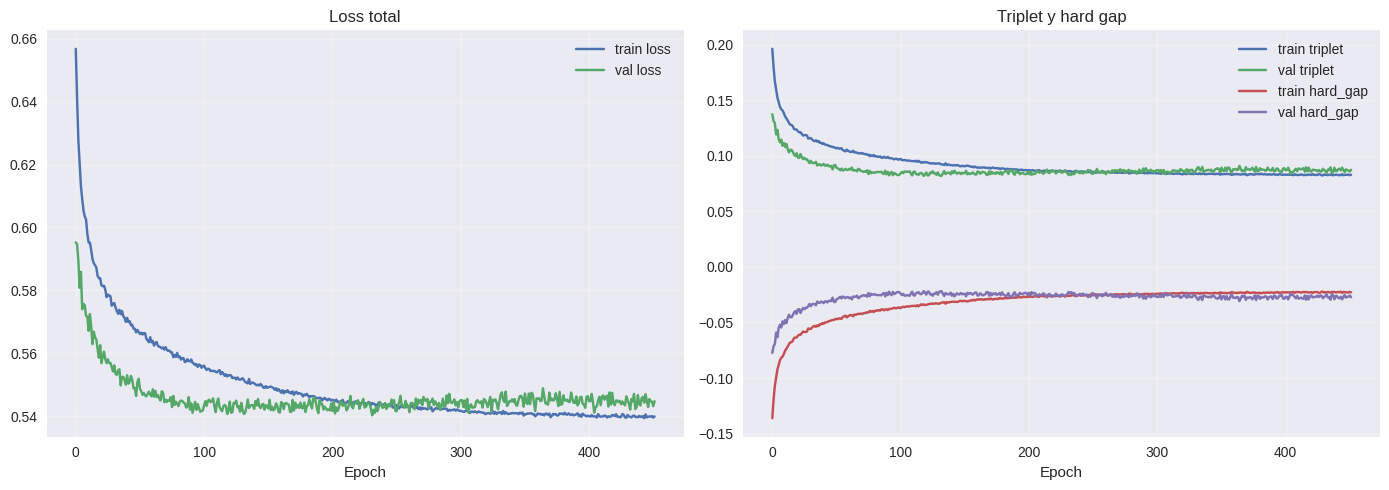

In [ ]:
history_csv_candidates = []
if "HISTORY_CSV_PATH" in globals():
    history_csv_candidates.append(Path(HISTORY_CSV_PATH))
history_csv_candidates.append(OUTPUT_BASE / "training_state" / "history.csv")

events_root = OUTPUT_BASE.parent if "OUTPUT_BASE" in globals() else None
if events_root is not None and events_root.exists():
    history_csv_candidates.extend(
        sorted(
            events_root.glob("*/training_state/history.csv"),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )
    )

unique_candidates = []
seen_candidates = set()
for candidate in history_csv_candidates:
    candidate = Path(candidate)
    if candidate in seen_candidates:
        continue
    seen_candidates.add(candidate)
    unique_candidates.append(candidate)

history_csv_path = next((p for p in unique_candidates if p.exists()), None)

history_current_df = pd.DataFrame(history.history) if "history" in globals() else pd.DataFrame()
if not history_current_df.empty and "epoch" not in history_current_df.columns:
    history_current_df = history_current_df.copy()
    history_current_df["epoch"] = np.arange(len(history_current_df), dtype=int)

if history_csv_path is not None:
    history_full_df = pd.read_csv(history_csv_path)
    if "epoch" not in history_full_df.columns:
        history_full_df = history_full_df.reset_index().rename(columns={"index": "epoch"})

    history_full_df = (
        history_full_df.sort_values("epoch")
        .drop_duplicates(subset=["epoch"], keep="last")
        .reset_index(drop=True)
    )

    if (
        not history_current_df.empty
        and not history_full_df.empty
        and history_current_df["epoch"].max() > history_full_df["epoch"].max()
    ):
        extra_current = history_current_df[
            history_current_df["epoch"] > history_full_df["epoch"].max()
        ]
        history_df = pd.concat([history_full_df, extra_current], ignore_index=True)
    elif not history_current_df.empty and history_full_df.empty:
        history_df = history_current_df
    else:
        history_df = history_full_df

    print(f"Usando historial completo desde {history_csv_path} ({len(history_df)} epochs)")
else:
    history_df = history_current_df
    if history_df.empty:
        raise RuntimeError(
            "No hay historial para graficar. Ejecuta entrenamiento o verifica history.csv."
        )
    print(f"Usando historial en memoria ({len(history_df)} epochs)")

x_epoch = history_df["epoch"] if "epoch" in history_df.columns else np.arange(len(history_df))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, label in [("loss", "train loss"), ("val_loss", "val loss")]:
    if col in history_df.columns:
        axes[0].plot(x_epoch, history_df[col], label=label)
axes[0].set_title("Loss total")
axes[0].set_xlabel("Epoch")
axes[0].grid(True, alpha=0.3)
if axes[0].lines:
    axes[0].legend()

for col, label in [
    ("triplet_loss", "train triplet"),
    ("val_triplet_loss", "val triplet"),
    ("hard_gap", "train hard_gap"),
    ("val_hard_gap", "val hard_gap"),
]:
    if col in history_df.columns:
        axes[1].plot(x_epoch, history_df[col], label=label)
axes[1].set_title("Triplet y hard gap")
axes[1].set_xlabel("Epoch")
axes[1].grid(True, alpha=0.3)
if axes[1].lines:
    axes[1].legend()

plt.tight_layout()
plt.show()


## 5) Hold-out(partidas no vistas) + evaluacion por memoria de partidas


In [ ]:
# Bootstrap HOLD-OUT al reanudar desde checkpoint sin ejecutar todas las celdas previas.
from pathlib import Path
import json
import re
import pandas as pd
import zstandard as zstd

if "chess" not in globals():
    import chess
    import chess.pgn
    import chess.svg
if "cv2" not in globals():
    import cv2
if "np" not in globals():
    import numpy as np

def _find_notebook_path():
    candidates = []
    if "REPO_ROOT" in globals():
        candidates.append(Path(REPO_ROOT) / "labs" / "notebooks" / "120_chess_siamese_instance_memory.ipynb")

    cwd = Path.cwd().resolve()
    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / "labs" / "notebooks" / "120_chess_siamese_instance_memory.ipynb")

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

def _load_symbol_from_notebook(symbol_name):
    notebook_path = _find_notebook_path()
    if notebook_path is None:
        return False

    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    needle = f"def {symbol_name}("
    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        if needle in source:
            exec(source, globals())
            return True
    return False

if "split_pgn_games" not in globals():
    def split_pgn_games(pgn_text):
        games = []
        current = []

        for line in pgn_text.splitlines():
            if line.startswith("[Event ") and current:
                games.append("\n".join(current).strip())
                current = []
            current.append(line)

        if current:
            games.append("\n".join(current).strip())

        return [g for g in games if g]

if "decompress_player_pgn_slice" not in globals():
    def decompress_player_pgn_slice(
        player_name,
        zst_path,
        output_dir,
        start_game_idx,
        max_games,
    ):
        output_dir.mkdir(parents=True, exist_ok=True)
        out_path = output_dir / f"{player_name}.pgn"

        dctx = zstd.ZstdDecompressor()
        with open(zst_path, "rb") as f:
            reader = dctx.stream_reader(f)
            full_text = reader.read().decode("utf-8", errors="replace")

        games = split_pgn_games(full_text)
        selected = games[start_game_idx : start_game_idx + max_games]

        with open(out_path, "w", encoding="utf-8") as f:
            f.write("\n\n".join(selected))

        return out_path, len(selected)

if "find_zst_path" not in globals():
    def find_zst_path(player_name):
        prefix = player_name[:2].lower()
        candidate = PLAYERS_DIR / prefix / f"{player_name}.pgn.zst"
        if candidate.exists():
            return candidate

        prefix_dir = PLAYERS_DIR / prefix
        if not prefix_dir.exists():
            return None

        target = f"{player_name.lower()}.pgn.zst"
        for file_path in prefix_dir.iterdir():
            if file_path.name.lower() == target:
                return file_path
        return None

def _ensure_event_dirs_with_train_players() -> List[str]:
    global OUTPUT_BASE, TRAIN_PGN_DIR, TRAIN_BOARD_DIR, TRAIN_HEAT_DIR
    global HOLDOUT_PGN_DIR, HOLDOUT_BOARD_DIR, HOLDOUT_HEAT_DIR

    def _player_dirs(board_dir: Path, heat_dir: Path) -> List[str]:
        if not board_dir.exists() or not heat_dir.exists():
            return []
        return sorted(
            d.name
            for d in board_dir.iterdir()
            if d.is_dir() and (heat_dir / d.name).is_dir()
        )

    current_players = _player_dirs(TRAIN_BOARD_DIR, TRAIN_HEAT_DIR)
    if current_players:
        return current_players

    events_root = OUTPUT_BASE.parent
    target_players = int(getattr(CONFIG, "players_count", 0)) if "CONFIG" in globals() else 0

    best_event = None
    best_players: List[str] = []
    best_score = None

    if events_root.exists():
        for event_dir in sorted(
            (d for d in events_root.iterdir() if d.is_dir()),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        ):
            train_players = _player_dirs(
                event_dir / "board_images",
                event_dir / "heatmap_images",
            )
            if not train_players:
                continue

            holdout_players = _player_dirs(
                event_dir / "holdout_board_images",
                event_dir / "holdout_heatmap_images",
            )
            has_history = (event_dir / "training_state" / "history.csv").exists()

            train_count = len(train_players)
            holdout_count = len(holdout_players)
            train_closeness = -abs(train_count - target_players) if target_players > 0 else train_count
            holdout_closeness = -abs(holdout_count - target_players) if target_players > 0 else holdout_count

            score = (
                1 if holdout_count > 0 else 0,
                1 if has_history else 0,
                train_closeness,
                holdout_closeness,
                -abs(train_count - holdout_count),
            )

            if best_score is None or score > best_score:
                best_score = score
                best_event = event_dir
                best_players = train_players

    if best_event is None or not best_players:
        return []

    OUTPUT_BASE = best_event
    TRAIN_PGN_DIR = OUTPUT_BASE / "pgn_train"
    TRAIN_BOARD_DIR = OUTPUT_BASE / "board_images"
    TRAIN_HEAT_DIR = OUTPUT_BASE / "heatmap_images"
    HOLDOUT_PGN_DIR = OUTPUT_BASE / "pgn_holdout"
    HOLDOUT_BOARD_DIR = OUTPUT_BASE / "holdout_board_images"
    HOLDOUT_HEAT_DIR = OUTPUT_BASE / "holdout_heatmap_images"

    training_state_dir = OUTPUT_BASE / "training_state"
    checkpoints_dir = training_state_dir / "checkpoints"
    backup_dir = training_state_dir / "backup"
    globals()["TRAINING_STATE_DIR"] = training_state_dir
    globals()["CHECKPOINTS_DIR"] = checkpoints_dir
    globals()["BACKUP_DIR"] = backup_dir
    globals()["BEST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_best.weights.h5"
    globals()["LAST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_last.weights.h5"
    globals()["HISTORY_CSV_PATH"] = training_state_dir / "history.csv"
    globals()["RUN_META_PATH"] = training_state_dir / "run_meta.json"

    for path in [training_state_dir, checkpoints_dir, backup_dir]:
        path.mkdir(parents=True, exist_ok=True)

    print(f"Evento ajustado automáticamente a: {OUTPUT_BASE.name}")
    return best_players

recovered_players = _ensure_event_dirs_with_train_players()

if "selected_players_df" not in globals() or "player" not in selected_players_df.columns:
    if "SELECTED_PLAYERS" in globals() and len(SELECTED_PLAYERS) > 0:
        selected_players_df = pd.DataFrame({"player": SELECTED_PLAYERS})
    else:
        inferred_players = recovered_players
        if not inferred_players:
            raise RuntimeError(
                "No hay jugadores para HOLD-OUT. Ejecuta antes la celda de selección/generación TRAIN o verifica OUTPUT_BASE."
            )
        selected_players_df = pd.DataFrame({"player": inferred_players})

if "zst_path" not in selected_players_df.columns or selected_players_df["zst_path"].isna().any():
    zst_paths = selected_players_df["player"].map(find_zst_path)
    missing_players = selected_players_df.loc[zst_paths.isna(), "player"].tolist()
    if missing_players:
        raise RuntimeError(f"No se encontró .pgn.zst para: {missing_players}")
    selected_players_df = selected_players_df.copy()
    selected_players_df["zst_path"] = zst_paths.map(str)

if "SELECTED_PLAYERS" not in globals():
    SELECTED_PLAYERS = selected_players_df["player"].tolist()

if "generate_player_centric_images" not in globals():
    loaded_helpers = _load_symbol_from_notebook("board_to_rgb_array")
    loaded_generator = _load_symbol_from_notebook("generate_player_centric_images")
    if not loaded_helpers or not loaded_generator or "generate_player_centric_images" not in globals():
        raise RuntimeError(
            "No se pudo restaurar generate_player_centric_images. Ejecuta la sección 2 del notebook."
        )

print(f"Bootstrap HOLD-OUT listo: {len(selected_players_df)} jugadores")


Bootstrap HOLD-OUT listo: 10 jugadores


In [ ]:
holdout_rows = []
for _, row in selected_players_df.iterrows():
    holdout_pgn, count = decompress_player_pgn_slice(
        player_name=row["player"],
        zst_path=row["zst_path"],
        output_dir=HOLDOUT_PGN_DIR,
        start_game_idx=CONFIG.games_per_player,
        max_games=CONFIG.holdout_games_per_player,
    )
    holdout_rows.append(
        {
            "player": row["player"],
            "pgn_path": str(holdout_pgn),
            "games": int(count),
        }
    )

holdout_df = pd.DataFrame(holdout_rows)
display(holdout_df)

holdout_image_rows = []
for _, row in holdout_df.iterrows():
    player = row["player"]
    print(f"Generando HOLD-OUT para {player}")

    stats = generate_player_centric_images(
        pgn_path=Path(row["pgn_path"]),
        player_name=player,
        output_board=HOLDOUT_BOARD_DIR / player,
        output_heat=HOLDOUT_HEAT_DIR / player,
        sequence_len=CONFIG.sequence_len,
        fullmove_start=CONFIG.fullmove_start,
        fullmove_end=CONFIG.fullmove_end,
        output_size=CONFIG.image_size[0],
        verbose=False,
    )
    stats["player"] = player
    holdout_image_rows.append(stats)

holdout_image_df = pd.DataFrame(holdout_image_rows)
display(holdout_image_df[["player", "games_processed", "games_skipped", "errors"]])

holdout_samples_by_player, holdout_stats_df = discover_game_samples(
    board_dir=HOLDOUT_BOARD_DIR,
    heat_dir=HOLDOUT_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=SELECTED_PLAYERS,
    min_samples=1,
)

display(holdout_stats_df)
HOLDOUT_SAMPLES = [
    s for per_player in holdout_samples_by_player.values() for s in per_player
]
print(f"Partidas hold-out válidas: {len(HOLDOUT_SAMPLES)}")

,player,pgn_path,games
0,sabino31,/workspace/code/labs/notebooks/output/events/c...,40
1,ujjawal305,/workspace/code/labs/notebooks/output/events/c...,40
2,Arsibbalt-1991,/workspace/code/labs/notebooks/output/events/c...,40
3,Migrant-is,/workspace/code/labs/notebooks/output/events/c...,40
4,edulol,/workspace/code/labs/notebooks/output/events/c...,40
5,shanis34,/workspace/code/labs/notebooks/output/events/c...,40
6,V2ethereum,/workspace/code/labs/notebooks/output/events/c...,40
7,RRusso,/workspace/code/labs/notebooks/output/events/c...,40
8,giliazov,/workspace/code/labs/notebooks/output/events/c...,40
9,Edssoto,/workspace/code/labs/notebooks/output/events/c...,40


,player,games_processed,games_skipped,errors
0,sabino31,40,0,0
1,ujjawal305,40,0,0
2,Arsibbalt-1991,40,0,0
3,Migrant-is,40,0,0
4,edulol,40,0,0
5,shanis34,40,0,0
6,V2ethereum,40,0,0
7,RRusso,40,0,0
8,giliazov,40,0,0
9,Edssoto,40,0,0


,player,games
0,Arsibbalt-1991,40
1,Edssoto,40
2,Migrant-is,40
3,RRusso,40
4,V2ethereum,40
5,edulol,40
6,giliazov,40
7,sabino31,40
8,shanis34,40
9,ujjawal305,40


In [ ]:
# Bootstrap EVAL al reanudar tras reinicio del kernel (sin reentrenar).
from pathlib import Path
import json
import gc
import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

if "tf" not in globals():
    import tensorflow as tf
from tensorflow.keras import Model, layers

if "chess" not in globals():
    import chess
    import chess.pgn
    import chess.svg

if "cv2" not in globals():
    import cv2


def _find_notebook_path():
    candidates = []
    if "REPO_ROOT" in globals():
        candidates.append(Path(REPO_ROOT) / "labs" / "notebooks" / "120_chess_siamese_instance_memory.ipynb")

    cwd = Path.cwd().resolve()
    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / "labs" / "notebooks" / "120_chess_siamese_instance_memory.ipynb")

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def _load_symbol_from_notebook(symbol_name):
    notebook_path = _find_notebook_path()
    if notebook_path is None:
        return False

    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    needles = (f"def {symbol_name}(", f"class {symbol_name}")

    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        if any(needle in source for needle in needles):
            exec(source, globals())
            return True
    return False


for symbol_name in [
    "GameSample",
    "discover_game_samples",
    "split_samples_by_player",
    "load_sequence_np",
    "build_embedding_model",
    "MetricTrainer",
]:
    if symbol_name not in globals():
        if not _load_symbol_from_notebook(symbol_name):
            raise RuntimeError(
                f"No se pudo restaurar '{symbol_name}'. Ejecuta la sección correspondiente antes de evaluar."
            )

def _ensure_event_dirs_with_train_players() -> List[str]:
    global OUTPUT_BASE, TRAIN_PGN_DIR, TRAIN_BOARD_DIR, TRAIN_HEAT_DIR
    global HOLDOUT_PGN_DIR, HOLDOUT_BOARD_DIR, HOLDOUT_HEAT_DIR

    def _player_dirs(board_dir: Path, heat_dir: Path) -> List[str]:
        if not board_dir.exists() or not heat_dir.exists():
            return []
        return sorted(
            d.name
            for d in board_dir.iterdir()
            if d.is_dir() and (heat_dir / d.name).is_dir()
        )

    current_players = _player_dirs(TRAIN_BOARD_DIR, TRAIN_HEAT_DIR)
    if current_players:
        return current_players

    events_root = OUTPUT_BASE.parent
    target_players = int(getattr(CONFIG, "players_count", 0)) if "CONFIG" in globals() else 0

    best_event = None
    best_players: List[str] = []
    best_score = None

    if events_root.exists():
        for event_dir in sorted(
            (d for d in events_root.iterdir() if d.is_dir()),
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        ):
            train_players = _player_dirs(
                event_dir / "board_images",
                event_dir / "heatmap_images",
            )
            if not train_players:
                continue

            holdout_players = _player_dirs(
                event_dir / "holdout_board_images",
                event_dir / "holdout_heatmap_images",
            )
            has_history = (event_dir / "training_state" / "history.csv").exists()

            train_count = len(train_players)
            holdout_count = len(holdout_players)
            train_closeness = -abs(train_count - target_players) if target_players > 0 else train_count
            holdout_closeness = -abs(holdout_count - target_players) if target_players > 0 else holdout_count

            score = (
                1 if holdout_count > 0 else 0,
                1 if has_history else 0,
                train_closeness,
                holdout_closeness,
                -abs(train_count - holdout_count),
            )

            if best_score is None or score > best_score:
                best_score = score
                best_event = event_dir
                best_players = train_players

    if best_event is None or not best_players:
        return []

    OUTPUT_BASE = best_event
    TRAIN_PGN_DIR = OUTPUT_BASE / "pgn_train"
    TRAIN_BOARD_DIR = OUTPUT_BASE / "board_images"
    TRAIN_HEAT_DIR = OUTPUT_BASE / "heatmap_images"
    HOLDOUT_PGN_DIR = OUTPUT_BASE / "pgn_holdout"
    HOLDOUT_BOARD_DIR = OUTPUT_BASE / "holdout_board_images"
    HOLDOUT_HEAT_DIR = OUTPUT_BASE / "holdout_heatmap_images"

    training_state_dir = OUTPUT_BASE / "training_state"
    checkpoints_dir = training_state_dir / "checkpoints"
    backup_dir = training_state_dir / "backup"
    globals()["TRAINING_STATE_DIR"] = training_state_dir
    globals()["CHECKPOINTS_DIR"] = checkpoints_dir
    globals()["BACKUP_DIR"] = backup_dir
    globals()["BEST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_best.weights.h5"
    globals()["LAST_WEIGHTS_PATH"] = checkpoints_dir / "metric_trainer_last.weights.h5"
    globals()["HISTORY_CSV_PATH"] = training_state_dir / "history.csv"
    globals()["RUN_META_PATH"] = training_state_dir / "run_meta.json"

    for path in [training_state_dir, checkpoints_dir, backup_dir]:
        path.mkdir(parents=True, exist_ok=True)

    print(f"Evento ajustado automáticamente a: {OUTPUT_BASE.name}")
    return best_players

recovered_players = _ensure_event_dirs_with_train_players()

if "SELECTED_PLAYERS" not in globals() or not SELECTED_PLAYERS:
    SELECTED_PLAYERS = recovered_players
    if not SELECTED_PLAYERS:
        raise RuntimeError(
            "No hay imágenes TRAIN para reconstruir el estado de evaluación. Verifica OUTPUT_BASE o ejecuta generación TRAIN."
        )

train_samples_by_player, train_stats_df = discover_game_samples(
    board_dir=TRAIN_BOARD_DIR,
    heat_dir=TRAIN_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=SELECTED_PLAYERS,
    min_samples=CONFIG.min_samples_per_player,
)
train_by_player, val_by_player, TRAIN_SAMPLES, VAL_SAMPLES = split_samples_by_player(
    samples_by_player=train_samples_by_player,
    val_fraction=CONFIG.validation_fraction,
    seed=CONFIG.seed,
)

PLAYER_TO_LABEL = {p: i for i, p in enumerate(sorted(train_by_player.keys()))}
LABEL_TO_PLAYER = {i: p for p, i in PLAYER_TO_LABEL.items()}

holdout_samples_by_player, holdout_stats_df = discover_game_samples(
    board_dir=HOLDOUT_BOARD_DIR,
    heat_dir=HOLDOUT_HEAT_DIR,
    labels=PLY_LABELS,
    players_whitelist=list(PLAYER_TO_LABEL.keys()),
    min_samples=1,
)
HOLDOUT_SAMPLES = [
    sample for per_player in holdout_samples_by_player.values() for sample in per_player
]

if "embedding_model" not in globals():
    embedding_model = build_embedding_model(
        seq_len=CONFIG.sequence_len,
        image_size=CONFIG.image_size,
        embedding_dim=CONFIG.embedding_dim,
    )

trainer = MetricTrainer(
    embedding_model=embedding_model,
    num_classes=len(PLAYER_TO_LABEL),
    margin=CONFIG.margin,
    ce_weight=CONFIG.ce_weight,
)

dummy_inputs = {
    "board_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 3),
        dtype=np.float32,
    ),
    "heat_sequence": np.zeros(
        (1, CONFIG.sequence_len, CONFIG.image_size[0], CONFIG.image_size[1], 1),
        dtype=np.float32,
    ),
}
_ = trainer(dummy_inputs, training=False)

checkpoint_candidates = []
for var_name in ["BEST_WEIGHTS_PATH", "LAST_WEIGHTS_PATH"]:
    if var_name in globals():
        checkpoint_candidates.append(Path(globals()[var_name]))

training_state_dir = OUTPUT_BASE / "training_state"
checkpoint_candidates.extend(
    sorted((training_state_dir / "checkpoints").glob("*.weights.h5"))
)
checkpoint_candidates.extend(sorted(training_state_dir.glob("*.weights.h5")))

events_root = OUTPUT_BASE.parent
if events_root.exists():
    checkpoint_candidates.extend(
        sorted(events_root.glob("*/training_state/checkpoints/*.weights.h5"))
    )
    checkpoint_candidates.extend(sorted(events_root.glob("*/training_state/*.weights.h5")))

deduped_candidates = []
seen = set()
for candidate in checkpoint_candidates:
    candidate = Path(candidate)
    if candidate in seen or not candidate.exists():
        continue
    seen.add(candidate)
    deduped_candidates.append(candidate)

loaded_checkpoint = None
for checkpoint_path in deduped_candidates:
    try:
        trainer.load_weights(str(checkpoint_path))
        loaded_checkpoint = checkpoint_path
        break
    except Exception:
        continue

if loaded_checkpoint is None:
    raise RuntimeError(
        "No se pudieron cargar pesos para evaluación. Revisa training_state/checkpoints o vuelve a cargar checkpoint de entrenamiento."
    )

embedding_model = trainer.embedding_model
gc.collect()

print(
    f"Bootstrap EVAL listo | TRAIN={len(TRAIN_SAMPLES)} | HOLDOUT={len(HOLDOUT_SAMPLES)} | pesos={loaded_checkpoint}"
)


In [ ]:
import gc
from typing import Dict, List, Tuple


def pairwise_distance_matrix(
    query_embeddings: np.ndarray,
    ref_embeddings: np.ndarray,
) -> np.ndarray:
    query = np.asarray(query_embeddings, dtype=np.float32)
    reference = np.asarray(ref_embeddings, dtype=np.float32)
    sims = np.clip(query @ reference.T, -1.0, 1.0)
    dist_sq = np.maximum(2.0 - 2.0 * sims, 0.0)
    return np.sqrt(dist_sq + 1e-12).astype(np.float32)


def aggregate_player_distances(
    query_to_ref_dists: np.ndarray,
    ref_labels: np.ndarray,
    num_players: int,
    top_k: int,
    strategy: str = "mean",
    temperature: float = 30.0,
) -> np.ndarray:
    strategy = str(strategy).strip().lower()
    if strategy not in {"mean", "softmin"}:
        raise ValueError("strategy debe ser 'mean' o 'softmin'.")

    out = np.full((query_to_ref_dists.shape[0], num_players), np.inf, dtype=np.float32)
    for player_idx in range(num_players):
        class_mask = ref_labels == player_idx
        class_dists = query_to_ref_dists[:, class_mask]
        if class_dists.size == 0:
            continue

        k = min(max(1, int(top_k)), class_dists.shape[1])
        topk = np.partition(class_dists, kth=k - 1, axis=1)[:, :k]
        topk.sort(axis=1)

        if strategy == "mean" or k == 1:
            out[:, player_idx] = topk.mean(axis=1)
            continue

        weights = np.exp(-float(temperature) * topk)
        weights_sum = np.maximum(weights.sum(axis=1, keepdims=True), 1e-8)
        out[:, player_idx] = np.sum(weights * topk, axis=1) / weights_sum[:, 0]

    return out


def retrieval_hit_at_k(
    query_to_ref_dists: np.ndarray,
    query_labels: np.ndarray,
    ref_labels: np.ndarray,
    k: int,
) -> float:
    if query_to_ref_dists.size == 0:
        return float("nan")
    k = min(max(1, int(k)), query_to_ref_dists.shape[1])
    topk_idx = np.argpartition(query_to_ref_dists, kth=k - 1, axis=1)[:, :k]
    topk_labels = ref_labels[topk_idx]
    hits = np.any(topk_labels == query_labels[:, None], axis=1)
    return float(np.mean(hits))


def build_reference_memory_df(
    samples: List[GameSample],
    labels: np.ndarray,
) -> pd.DataFrame:
    rows = []
    for ref_idx, sample in enumerate(samples):
        rows.append(
            {
                "ref_index": ref_idx,
                "player": sample.player,
                "label": int(labels[ref_idx]),
                "game_id": sample.game_id,
            }
        )
    return pd.DataFrame(rows)


def embed_samples_streaming(
    samples: List[GameSample],
    player_to_label: Dict[str, int],
    image_size: Tuple[int, int],
    batch_size: int = 4,
    tag: str = "SAMPLES",
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    if not samples:
        raise RuntimeError(f"No hay muestras para {tag}.")

    emb_chunks: List[np.ndarray] = []
    label_chunks: List[np.ndarray] = []
    players: List[str] = []

    total = len(samples)
    for start in range(0, total, batch_size):
        batch = samples[start : start + batch_size]

        boards = []
        heats = []
        labels = []
        for sample in batch:
            board_seq, heat_seq = load_sequence_np(sample, image_size)
            boards.append(board_seq)
            heats.append(heat_seq)
            labels.append(player_to_label[sample.player])
            players.append(sample.player)

        boards_np = np.stack(boards).astype(np.float32)
        heats_np = np.stack(heats).astype(np.float32)
        labels_np = np.array(labels, dtype=np.int32)

        emb_batch = embedding_model.predict(
            {"board_sequence": boards_np, "heat_sequence": heats_np},
            batch_size=len(batch),
            verbose=0,
        )
        emb_chunks.append(emb_batch.astype(np.float32))
        label_chunks.append(labels_np)

        processed = min(start + batch_size, total)
        print(f"{tag}: {processed}/{total}")

        del boards_np, heats_np, labels_np, emb_batch, boards, heats, labels
        gc.collect()

    embeddings = np.vstack(emb_chunks)
    labels = np.concatenate(label_chunks)
    return embeddings, labels, players


def evaluate_player_distance_method(
    player_dists: np.ndarray,
    true_labels: np.ndarray,
) -> Dict[str, np.ndarray | float]:
    player_dists = np.asarray(player_dists, dtype=np.float32)
    true_labels = np.asarray(true_labels, dtype=np.int32)

    scores = -player_dists
    pred = np.argmin(player_dists, axis=1)
    sorted_idx = np.argsort(player_dists, axis=1)

    true_rank = np.empty(len(true_labels), dtype=np.int32)
    for row_idx in range(len(true_labels)):
        true_rank[row_idx] = int(
            np.flatnonzero(sorted_idx[row_idx] == true_labels[row_idx])[0]
        ) + 1

    top3_contains_true = np.any(
        sorted_idx[:, : min(3, player_dists.shape[1])] == true_labels[:, None],
        axis=1,
    )
    top5_contains_true = np.any(
        sorted_idx[:, : min(5, player_dists.shape[1])] == true_labels[:, None],
        axis=1,
    )

    own_memory_dist = player_dists[np.arange(len(true_labels)), true_labels].astype(
        np.float32
    )
    mask_other_player = np.ones_like(player_dists, dtype=bool)
    mask_other_player[np.arange(len(true_labels)), true_labels] = False
    other_memory_dist = np.min(
        np.where(mask_other_player, player_dists, np.inf),
        axis=1,
    ).astype(np.float32)
    memory_gap = (other_memory_dist - own_memory_dist).astype(np.float32)

    if player_dists.shape[1] >= 2:
        top2 = np.partition(player_dists, kth=1, axis=1)[:, :2]
        top2.sort(axis=1)
        top1_margin = (top2[:, 1] - top2[:, 0]).astype(np.float32)
    else:
        top1_margin = np.full(len(true_labels), np.nan, dtype=np.float32)

    num_players = player_dists.shape[1]
    return {
        "scores": scores,
        "pred": pred,
        "sorted_idx": sorted_idx,
        "true_rank": true_rank,
        "top3_contains_true": top3_contains_true,
        "top5_contains_true": top5_contains_true,
        "own_memory_dist": own_memory_dist,
        "other_memory_dist": other_memory_dist,
        "memory_gap": memory_gap,
        "top1_margin": top1_margin,
        "top1": float(
            top_k_accuracy_score(
                true_labels,
                scores,
                k=1,
                labels=np.arange(num_players),
            )
        ),
        "top3": float(
            top_k_accuracy_score(
                true_labels,
                scores,
                k=min(3, num_players),
                labels=np.arange(num_players),
            )
        ),
        "top5": float(
            top_k_accuracy_score(
                true_labels,
                scores,
                k=min(5, num_players),
                labels=np.arange(num_players),
            )
        ),
    }


train_embeddings, train_labels, train_players = embed_samples_streaming(
    TRAIN_SAMPLES,
    PLAYER_TO_LABEL,
    CONFIG.image_size,
    batch_size=4,
    tag="TRAIN",
)
hold_embeddings, hold_labels, hold_players = embed_samples_streaming(
    HOLDOUT_SAMPLES,
    PLAYER_TO_LABEL,
    CONFIG.image_size,
    batch_size=4,
    tag="HOLDOUT",
)

num_classes = len(PLAYER_TO_LABEL)
reference_players = [LABEL_TO_PLAYER[i] for i in range(num_classes)]

reference_memory_df = build_reference_memory_df(TRAIN_SAMPLES, train_labels)
reference_memory_summary_df = (
    reference_memory_df.groupby("player", as_index=False)
    .agg(reference_games=("game_id", "count"))
    .sort_values(["reference_games", "player"], ascending=[False, True])
    .reset_index(drop=True)
)

query_to_ref_dists = pairwise_distance_matrix(hold_embeddings, train_embeddings)

PLAYER_METHOD_SPECS = {
    "mean_topk": {
        "label": f"mean(top-{CONFIG.exemplar_top_k})",
        "top_k": int(CONFIG.exemplar_top_k),
        "strategy": "mean",
    },
    "softmin_topk": {
        "label": f"softmin(top-{CONFIG.exemplar_top_k})",
        "top_k": int(CONFIG.exemplar_top_k),
        "strategy": "softmin",
    },
    "nn1": {
        "label": "1-NN puro",
        "top_k": 1,
        "strategy": "mean",
    },
}
PRIMARY_METHOD_KEY = (
    "softmin_topk"
    if str(CONFIG.exemplar_strategy).strip().lower() == "softmin"
    else "mean_topk"
)
PRIMARY_METHOD_LABEL = PLAYER_METHOD_SPECS[PRIMARY_METHOD_KEY]["label"]
PLAYER_METHOD_ALIASES = {
    "mean": "mean_topk",
    "mean_topk": "mean_topk",
    "mean(top-k)": "mean_topk",
    "softmin": "softmin_topk",
    "softmin_topk": "softmin_topk",
    "softmin(top-k)": "softmin_topk",
    "nn": "nn1",
    "1-nn": "nn1",
    "1nn": "nn1",
    "nn1": "nn1",
    "1-nn puro": "nn1",
}


def resolve_player_method_key(method: str = "config") -> str:
    normalized = str(method or "config").strip().lower()
    if normalized in {"config", "default", "primary"}:
        return PRIMARY_METHOD_KEY
    if normalized not in PLAYER_METHOD_ALIASES:
        valid = ", ".join(sorted({*PLAYER_METHOD_ALIASES.keys(), "config"}))
        raise ValueError(f"Metodo desconocido: {method}. Opciones: {valid}")
    return PLAYER_METHOD_ALIASES[normalized]


def compute_player_distance_methods(
    query_to_ref_dists: np.ndarray,
    ref_labels: np.ndarray,
    num_players: int,
    true_labels: np.ndarray,
) -> Dict[str, Dict[str, np.ndarray | float | int | str]]:
    outputs: Dict[str, Dict[str, np.ndarray | float | int | str]] = {}
    for method_key, spec in PLAYER_METHOD_SPECS.items():
        player_dists = aggregate_player_distances(
            query_to_ref_dists,
            ref_labels,
            num_players=num_players,
            top_k=spec["top_k"],
            strategy=spec["strategy"],
            temperature=CONFIG.softmin_temperature,
        )
        outputs[method_key] = {
            "method_key": method_key,
            "method": spec["label"],
            "method_label": spec["label"],
            "strategy": spec["strategy"],
            "aggregation_top_k": int(spec["top_k"]),
            "player_dists": player_dists,
            **evaluate_player_distance_method(player_dists, true_labels),
        }
    return outputs


player_method_outputs = compute_player_distance_methods(
    query_to_ref_dists,
    train_labels,
    num_players=num_classes,
    true_labels=hold_labels,
)

nearest_ref_idx = np.argmin(query_to_ref_dists, axis=1)
nn_pred = train_labels[nearest_ref_idx]
nn_acc = float(player_method_outputs["nn1"]["top1"])
hit_at1 = retrieval_hit_at_k(query_to_ref_dists, hold_labels, train_labels, k=1)
hit_at3 = retrieval_hit_at_k(query_to_ref_dists, hold_labels, train_labels, k=3)
hit_at5 = retrieval_hit_at_k(query_to_ref_dists, hold_labels, train_labels, k=5)

centroid_matrix = []
for class_idx in range(num_classes):
    class_emb = train_embeddings[train_labels == class_idx]
    if class_emb.size == 0:
        raise RuntimeError(f"Sin embeddings TRAIN para clase {class_idx}.")
    centroid_matrix.append(class_emb.mean(axis=0))
centroid_matrix = np.vstack(centroid_matrix).astype(np.float32)
centroid_matrix /= np.clip(
    np.linalg.norm(centroid_matrix, axis=1, keepdims=True),
    1e-8,
    None,
)

centroid_dists = pairwise_distance_matrix(hold_embeddings, centroid_matrix)
centroid_scores = -centroid_dists
centroid_pred = np.argmin(centroid_dists, axis=1)

centroid_top1 = top_k_accuracy_score(
    hold_labels, centroid_scores, k=1, labels=np.arange(num_classes)
)
centroid_top3 = top_k_accuracy_score(
    hold_labels,
    centroid_scores,
    k=min(3, num_classes),
    labels=np.arange(num_classes),
)
centroid_top5 = top_k_accuracy_score(
    hold_labels,
    centroid_scores,
    k=min(5, num_classes),
    labels=np.arange(num_classes),
)

method_comparison_rows = []
per_player_method_rows = []
report_by_method = {}
for method_key, method_output in player_method_outputs.items():
    report_dict = classification_report(
        hold_labels,
        method_output["pred"],
        labels=np.arange(num_classes),
        target_names=reference_players,
        output_dict=True,
        zero_division=0,
    )
    report_by_method[method_key] = pd.DataFrame(report_dict).T

    cm_method = confusion_matrix(
        hold_labels,
        method_output["pred"],
        labels=np.arange(len(reference_players)),
    )
    for idx, player in enumerate(reference_players):
        support = int(cm_method[idx].sum())
        correct = int(cm_method[idx, idx])
        recall = (correct / support) if support > 0 else np.nan
        per_player_method_rows.append(
            {
                "method_key": method_key,
                "method": method_output["method"],
                "player": player,
                "elo": PLAYER_ELO.get(player, np.nan),
                "support": support,
                "correct": correct,
                "recall": recall,
            }
        )

    method_comparison_rows.append(
        {
            "method_key": method_key,
            "method": method_output["method"],
            "is_primary": bool(method_key == PRIMARY_METHOD_KEY),
            "top1": float(method_output["top1"]),
            "top3": float(method_output["top3"]),
            "top5": float(method_output["top5"]),
            "positive_memory_gap": float(np.mean(method_output["memory_gap"] > 0)),
            "mean_memory_gap": float(np.mean(method_output["memory_gap"])),
            "median_memory_gap": float(np.median(method_output["memory_gap"])),
            "mean_true_rank": float(np.mean(method_output["true_rank"])),
            "median_true_rank": float(np.median(method_output["true_rank"])),
            "mean_top1_margin": float(np.nanmean(method_output["top1_margin"])),
        }
    )

method_comparison_df = (
    pd.DataFrame(method_comparison_rows)
    .sort_values(["top1", "mean_memory_gap", "method"], ascending=[False, False, True])
    .reset_index(drop=True)
)
per_player_method_eval_df = pd.DataFrame(per_player_method_rows)

primary_output = player_method_outputs[PRIMARY_METHOD_KEY]
memory_player_dists = primary_output["player_dists"]
memory_scores = primary_output["scores"]
memory_pred = primary_output["pred"]
memory_top1 = float(primary_output["top1"])
memory_top3 = float(primary_output["top3"])
memory_top5 = float(primary_output["top5"])
memory_true_rank = primary_output["true_rank"]
memory_top1_margin = primary_output["top1_margin"]
report_df = report_by_method[PRIMARY_METHOD_KEY]
per_player_eval_df = (
    per_player_method_eval_df.loc[
        per_player_method_eval_df["method_key"] == PRIMARY_METHOD_KEY
    ]
    .sort_values("elo")
    .reset_index(drop=True)
)

baseline_eval_df = pd.DataFrame(
    [
        {
            "baseline": "Centroid (110)",
            "top1": float(centroid_top1),
            "top3": float(centroid_top3),
            "top5": float(centroid_top5),
        },
        {
            "baseline": "Exemplar hit@k",
            "top1": float(hit_at1),
            "top3": float(hit_at3),
            "top5": float(hit_at5),
        },
    ]
)

nearest_match_rows = []
for hold_idx, ref_idx in enumerate(nearest_ref_idx):
    query_sample = HOLDOUT_SAMPLES[hold_idx]
    ref_sample = TRAIN_SAMPLES[ref_idx]
    nearest_match_rows.append(
        {
            "query_player": query_sample.player,
            "query_game_id": query_sample.game_id,
            "match_player": ref_sample.player,
            "match_game_id": ref_sample.game_id,
            "distance": float(query_to_ref_dists[hold_idx, ref_idx]),
            "same_player": bool(query_sample.player == ref_sample.player),
        }
    )
nearest_match_df = pd.DataFrame(nearest_match_rows)

print("=" * 80)
print("MEMORIA DE PARTIDAS · HOLD-OUT")
print("=" * 80)
print(f"Referencias TRAIN: {len(TRAIN_SAMPLES)} partidas | {num_classes} jugadores")
print(f"Metodo primario del notebook: {PRIMARY_METHOD_LABEL}")
print("-" * 80)
for row in method_comparison_df.itertuples(index=False):
    primary_mark = " [primary]" if row.is_primary else ""
    print(
        f"{row.method:<18} | Top-1 {row.top1:.2%} | Top-3 {row.top3:.2%} | "
        f"Top-5 {row.top5:.2%} | gap>0 {row.positive_memory_gap:.2%} | "
        f"gap medio {row.mean_memory_gap:.6f}{primary_mark}"
    )
print("-" * 80)
print(f"Hit@1 exemplar:       {hit_at1:.2%}")
print(f"Hit@3 exemplar:       {hit_at3:.2%}")
print(f"Hit@5 exemplar:       {hit_at5:.2%}")
print(f"Baseline centroid Top-1 (110): {centroid_top1:.2%}")
print(f"Baseline centroid Top-3 (110): {centroid_top3:.2%}")
print(f"Baseline centroid Top-5 (110): {centroid_top5:.2%}")
print(f"Partidas hold-out evaluadas:   {len(hold_labels)}")
print("=" * 80)

display(method_comparison_df)
display(baseline_eval_df)
display(reference_memory_summary_df)
display(per_player_eval_df.assign(recall_pct=lambda df: df["recall"] * 100.0))
display(report_df.loc[[*reference_players, "accuracy", "macro avg", "weighted avg"]])


,method_key,method,is_primary,top1,top3,top5,positive_memory_gap,mean_memory_gap,median_memory_gap,mean_true_rank,median_true_rank,mean_top1_margin
0,mean_topk,mean(top-5),True,0.2850,0.5725,0.7625,0.285,-0.002644,-0.002594,3.5600,3.0,0.002652
1,softmin_topk,softmin(top-5),False,0.2800,0.5700,0.7525,0.280,-0.002923,-0.002856,3.6025,3.0,0.002814
2,nn1,1-NN puro,False,0.2325,0.5225,0.7025,0.210,-0.004968,-0.004810,3.9375,3.0,0.003562


,baseline,top1,top3,top5
0,Centroid (110),0.325,0.6325,0.800
1,Exemplar hit@k,0.240,0.4725,0.595


,player,reference_games
0,Arsibbalt-1991,144
1,Edssoto,144
2,Migrant-is,144
3,RRusso,144
4,V2ethereum,144
5,edulol,144
6,giliazov,144
7,sabino31,144
8,shanis34,144
9,ujjawal305,144


,method_key,method,player,elo,support,correct,recall,recall_pct
0,mean_topk,mean(top-5),sabino31,755,40,25,0.625,62.5
1,mean_topk,mean(top-5),ujjawal305,941,40,16,0.400,40.0
2,mean_topk,mean(top-5),Arsibbalt-1991,1197,40,5,0.125,12.5
3,mean_topk,mean(top-5),Migrant-is,1229,40,12,0.300,30.0
4,mean_topk,mean(top-5),edulol,1460,40,6,0.150,15.0
5,mean_topk,mean(top-5),shanis34,1653,40,5,0.125,12.5
6,mean_topk,mean(top-5),V2ethereum,1889,40,5,0.125,12.5
7,mean_topk,mean(top-5),RRusso,1904,40,13,0.325,32.5
8,mean_topk,mean(top-5),giliazov,2006,40,11,0.275,27.5
9,mean_topk,mean(top-5),Edssoto,2280,40,17,0.425,42.5


,precision,recall,f1-score,support
Arsibbalt-1991,0.128205,0.1250,0.126582,40.0000
Edssoto,0.184783,0.4250,0.257576,40.0000
Migrant-is,0.244898,0.3000,0.269663,40.0000
RRusso,0.371429,0.3250,0.346667,40.0000
V2ethereum,0.192308,0.1250,0.151515,40.0000
edulol,0.166667,0.1500,0.157895,40.0000
giliazov,0.423077,0.2750,0.333333,40.0000
sabino31,0.520833,0.6250,0.568182,40.0000
shanis34,0.416667,0.1250,0.192308,40.0000
ujjawal305,0.432432,0.4000,0.415584,40.0000


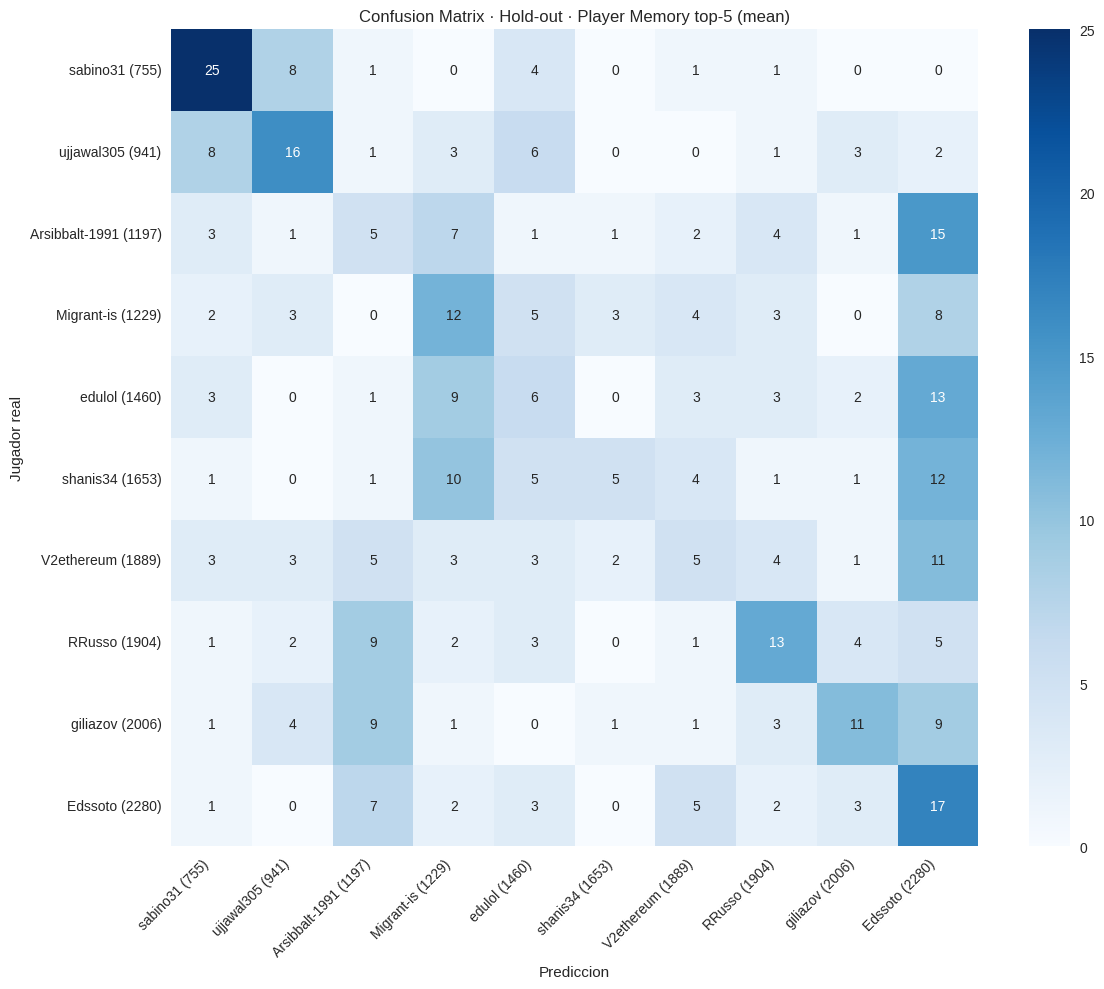

In [ ]:
elo_by_player = {}

if "selected_players_df" in globals() and {"player", "elo"}.issubset(selected_players_df.columns):
    for _, row in selected_players_df[["player", "elo"]].drop_duplicates("player").iterrows():
        try:
            elo_by_player[str(row["player"])] = float(row["elo"])
        except Exception:
            continue

if "PLAYER_ELO" in globals() and isinstance(PLAYER_ELO, dict):
    for player, elo in PLAYER_ELO.items():
        try:
            elo_val = float(elo)
        except Exception:
            continue
        if not np.isnan(elo_val):
            elo_by_player[str(player)] = elo_val


def _elo_sort_key(player: str):
    elo = elo_by_player.get(player, np.nan)
    if np.isnan(elo):
        return (1, float("inf"), player.lower())
    return (0, elo, player.lower())


ordered_players = sorted(reference_players, key=_elo_sort_key)
order_idx = [reference_players.index(player) for player in ordered_players]

cm = confusion_matrix(
    hold_labels, memory_pred, labels=np.arange(len(reference_players))
)
cm_ordered = cm[np.ix_(order_idx, order_idx)]

ordered_labels = []
for player in ordered_players:
    elo = elo_by_player.get(player, np.nan)
    if np.isnan(elo):
        ordered_labels.append(f"{player} (ELO ?)")
    else:
        ordered_labels.append(f"{player} ({int(round(elo))})")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_ordered,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ordered_labels,
    yticklabels=ordered_labels,
    ax=ax,
)
ax.set_title(
    f"Confusion Matrix · Hold-out · Player Memory top-{CONFIG.exemplar_top_k} ({CONFIG.exemplar_strategy})"
)
ax.set_xlabel("Prediccion")
ax.set_ylabel("Jugador real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


,method_key,method,is_primary,top1_acc,top3_acc,top5_acc,positive_memory_gap,mean_memory_gap,median_memory_gap,positive_exemplar_gap,mean_exemplar_gap,median_exemplar_gap,mean_true_rank,median_true_rank,mean_top1_margin
0,mean_topk,mean(top-5),True,0.2850,0.5725,0.7625,0.285,-0.002644,-0.002594,0.21,-0.004968,-0.00481,3.5600,3.0,0.002652
1,softmin_topk,softmin(top-5),False,0.2800,0.5700,0.7525,0.280,-0.002923,-0.002856,0.21,-0.004968,-0.00481,3.6025,3.0,0.002814
2,nn1,1-NN puro,False,0.2325,0.5225,0.7025,0.210,-0.004968,-0.004810,0.21,-0.004968,-0.00481,3.9375,3.0,0.003562


,method_key,method,quantile,memory_gap,exemplar_gap,top1_margin
0,mean_topk,mean(top-5),p10,-0.009510,-0.015573,0.000276
1,mean_topk,mean(top-5),p25,-0.005527,-0.009561,0.000634
2,mean_topk,mean(top-5),p50,-0.002594,-0.004810,0.001612
3,mean_topk,mean(top-5),p75,0.000566,0.000000,0.003527
4,mean_topk,mean(top-5),p90,0.003580,0.004325,0.005963
5,softmin_topk,softmin(top-5),p10,-0.010261,-0.015573,0.000262
6,softmin_topk,softmin(top-5),p25,-0.006294,-0.009561,0.000731
7,softmin_topk,softmin(top-5),p50,-0.002856,-0.004810,0.001867
8,softmin_topk,softmin(top-5),p75,0.000534,0.000000,0.003676
9,softmin_topk,softmin(top-5),p90,0.003550,0.004325,0.006490


,method_key,method,true_player,support,top1_acc,top3_acc,top5_acc,mean_memory_gap,median_memory_gap,positive_memory_gap,mean_exemplar_gap,median_exemplar_gap,positive_exemplar_gap,mean_true_rank,median_true_rank,mean_top1_margin
0,nn1,1-NN puro,sabino31,40,0.525,0.725,0.775,0.001635,0.000168,0.525,0.001635,0.000168,0.525,3.000,1.0,0.006160
1,nn1,1-NN puro,RRusso,40,0.225,0.600,0.900,-0.002900,-0.002565,0.175,-0.002900,-0.002565,0.175,3.250,3.0,0.002913
2,nn1,1-NN puro,giliazov,40,0.225,0.400,0.625,-0.004826,-0.007209,0.225,-0.004826,-0.007209,0.225,4.425,4.0,0.003918
3,nn1,1-NN puro,shanis34,40,0.150,0.475,0.650,-0.005379,-0.005306,0.150,-0.005379,-0.005306,0.150,4.475,4.0,0.003231
4,nn1,1-NN puro,Edssoto,40,0.250,0.725,0.825,-0.005541,-0.003874,0.150,-0.005541,-0.003874,0.150,3.275,2.5,0.003204
5,nn1,1-NN puro,ujjawal305,40,0.275,0.625,0.675,-0.005568,-0.003530,0.275,-0.005568,-0.003530,0.275,3.775,2.5,0.004142
6,nn1,1-NN puro,edulol,40,0.200,0.450,0.700,-0.006127,-0.006599,0.200,-0.006127,-0.006599,0.200,3.850,4.0,0.003521
7,nn1,1-NN puro,Arsibbalt-1991,40,0.275,0.450,0.675,-0.006841,-0.005267,0.125,-0.006841,-0.005267,0.125,4.075,4.0,0.002808
8,nn1,1-NN puro,Migrant-is,40,0.175,0.450,0.625,-0.006894,-0.005823,0.175,-0.006894,-0.005823,0.175,4.200,4.0,0.002571
9,nn1,1-NN puro,V2ethereum,40,0.100,0.250,0.525,-0.007237,-0.007293,0.100,-0.007237,-0.007293,0.100,5.050,5.0,0.003153


,method_key,method,query_index,true_player,true_game_id,pred_player,is_correct,true_player_rank,top3_contains_true,top5_contains_true,...,exemplar_gap,own_memory_dist,other_memory_dist,memory_gap,top1_margin,nearest_ref_player,nearest_ref_game_id,nearest_ref_dist,top3_pred_players,top3_support_refs
0,nn1,1-NN puro,39,Arsibbalt-1991,0040,sabino31,False,7,False,False,...,-0.038774,0.038775,1.000000e-06,-0.038774,0.026055,sabino31,0051,1.000000e-06,"sabino31, ujjawal305, shanis34","sabino31:0051:0.0000, sabino31:0090:0.0101, sa..."
1,nn1,1-NN puro,386,ujjawal305,0027,shanis34,False,9,False,False,...,-0.033706,0.033707,1.000000e-06,-0.033706,0.018098,shanis34,0007,1.000000e-06,"shanis34, edulol, sabino31","shanis34:0007:0.0000, edulol:0138:0.0181, sabi..."
2,nn1,1-NN puro,394,ujjawal305,0035,Migrant-is,False,10,False,False,...,-0.030984,0.035310,4.326183e-03,-0.030984,0.016701,Migrant-is,0058,4.326183e-03,"Migrant-is, V2ethereum, edulol","Migrant-is:0058:0.0043, V2ethereum:0120:0.0210..."
3,nn1,1-NN puro,72,Edssoto,0033,Arsibbalt-1991,False,9,False,False,...,-0.027944,0.027945,1.000000e-06,-0.027944,0.000000,Arsibbalt-1991,0175,1.000000e-06,"Arsibbalt-1991, RRusso, giliazov","RRusso:0161:0.0000, Arsibbalt-1991:0175:0.0000..."
4,nn1,1-NN puro,338,shanis34,0019,Edssoto,False,7,False,False,...,-0.026881,0.026882,1.000000e-06,-0.026881,0.017318,Edssoto,0090,1.000000e-06,"Edssoto, RRusso, Arsibbalt-1991","Edssoto:0090:0.0000, RRusso:0041:0.0173, Arsib..."
5,nn1,1-NN puro,165,V2ethereum,0006,Arsibbalt-1991,False,10,False,False,...,-0.025910,0.025911,1.000000e-06,-0.025910,0.000000,Arsibbalt-1991,0122,1.000000e-06,"Arsibbalt-1991, Edssoto, RRusso","Edssoto:0160:0.0000, sabino31:0118:0.0000, Ars..."
6,nn1,1-NN puro,95,Migrant-is,0016,sabino31,False,7,False,False,...,-0.024805,0.038412,1.360632e-02,-0.024805,0.011831,sabino31,0118,1.360632e-02,"sabino31, shanis34, edulol","sabino31:0118:0.0136, shanis34:0007:0.0254, sa..."
7,nn1,1-NN puro,295,sabino31,0016,Edssoto,False,10,False,False,...,-0.022836,0.022837,1.000000e-06,-0.022836,0.000000,Edssoto,0098,1.000000e-06,"Edssoto, ujjawal305, edulol","ujjawal305:0051:0.0000, Edssoto:0098:0.0000, u..."
8,nn1,1-NN puro,176,V2ethereum,0017,Arsibbalt-1991,False,8,False,False,...,-0.022747,0.022748,1.000000e-06,-0.022747,0.000000,Arsibbalt-1991,0165,1.000000e-06,"Arsibbalt-1991, Edssoto, RRusso","RRusso:0086:0.0000, Arsibbalt-1991:0165:0.0000..."
9,nn1,1-NN puro,94,Migrant-is,0015,RRusso,False,6,False,False,...,-0.022745,0.022746,1.000000e-06,-0.022745,0.000000,RRusso,0084,1.000000e-06,"RRusso, edulol, shanis34","shanis34:0088:0.0000, RRusso:0084:0.0000, shan..."


,method_key,method,query_index,true_player,true_game_id,pred_player,is_correct,true_player_rank,top3_contains_true,top5_contains_true,...,exemplar_gap,own_memory_dist,other_memory_dist,memory_gap,top1_margin,nearest_ref_player,nearest_ref_game_id,nearest_ref_dist,top3_pred_players,top3_support_refs
0,nn1,1-NN puro,306,sabino31,0027,sabino31,True,1,True,True,...,0.047445,1.000000e-06,0.047446,0.047445,0.047445,sabino31,0017,1.000000e-06,"sabino31, shanis34, edulol","sabino31:0017:0.0000, sabino31:0018:0.0189, sa..."
1,nn1,1-NN puro,307,sabino31,0028,sabino31,True,1,True,True,...,0.036542,1.000000e-06,0.036543,0.036542,0.036542,sabino31,0154,1.000000e-06,"sabino31, ujjawal305, Migrant-is","sabino31:0154:0.0000, sabino31:0180:0.0089, sa..."
2,nn1,1-NN puro,273,giliazov,0034,giliazov,True,1,True,True,...,0.016842,8.768694e-03,0.025610,0.016842,0.016842,giliazov,0089,8.768694e-03,"giliazov, V2ethereum, Arsibbalt-1991","giliazov:0089:0.0088, giliazov:0120:0.0155, gi..."
3,nn1,1-NN puro,53,Edssoto,0014,Edssoto,True,1,True,True,...,0.015053,1.000000e-06,0.015054,0.015053,0.015053,Edssoto,0126,1.000000e-06,"Edssoto, giliazov, RRusso","Edssoto:0126:0.0000, giliazov:0130:0.0151, gil..."
4,nn1,1-NN puro,227,edulol,0028,edulol,True,1,True,True,...,0.014890,1.000000e-06,0.014891,0.014890,0.014890,edulol,0138,1.000000e-06,"edulol, Arsibbalt-1991, RRusso","edulol:0138:0.0000, Arsibbalt-1991:0107:0.0149..."
5,nn1,1-NN puro,282,sabino31,0003,sabino31,True,1,True,True,...,0.014061,1.006618e-02,0.024127,0.014061,0.014061,sabino31,0090,1.006618e-02,"sabino31, ujjawal305, edulol","sabino31:0090:0.0101, sabino31:0051:0.0197, sa..."
6,nn1,1-NN puro,177,V2ethereum,0018,V2ethereum,True,1,True,True,...,0.013535,1.000000e-06,0.013536,0.013535,0.013535,V2ethereum,0017,1.000000e-06,"V2ethereum, Edssoto, edulol","V2ethereum:0017:0.0000, Edssoto:0069:0.0135, V..."
7,nn1,1-NN puro,298,sabino31,0019,sabino31,True,1,True,True,...,0.012346,1.836742e-02,0.030713,0.012346,0.012346,sabino31,0138,1.836742e-02,"sabino31, Edssoto, edulol","sabino31:0138:0.0184, sabino31:0118:0.0201, sa..."
8,nn1,1-NN puro,290,sabino31,0011,sabino31,True,1,True,True,...,0.012342,3.066663e-02,0.043009,0.012342,0.012342,sabino31,0180,3.066663e-02,"sabino31, ujjawal305, Migrant-is","sabino31:0180:0.0307, sabino31:0117:0.0327, sa..."
9,nn1,1-NN puro,272,giliazov,0033,giliazov,True,1,True,True,...,0.012251,6.956937e-03,0.019208,0.012251,0.012251,giliazov,0009,6.956937e-03,"giliazov, shanis34, Edssoto","giliazov:0009:0.0070, giliazov:0129:0.0085, gi..."


...

,quantile,memory_gap,exemplar_gap,top1_margin
0,p10,-0.009510,-0.015573,0.000276
1,p25,-0.005527,-0.009561,0.000634
2,p50,-0.002594,-0.004810,0.001612
3,p75,0.000566,0.000000,0.003527
4,p90,0.003580,0.004325,0.005963


,true_player,support,top1_acc,top3_acc,top5_acc,mean_memory_gap,median_memory_gap,positive_memory_gap,mean_exemplar_gap,median_exemplar_gap,positive_exemplar_gap,mean_true_rank,median_true_rank,mean_top1_margin
0,sabino31,40,0.625,0.800,0.825,0.001793,0.001145,0.625,0.001635,0.000168,0.525,2.575,1.0,0.005320
1,RRusso,40,0.325,0.800,0.875,-0.001510,-0.001546,0.325,-0.002900,-0.002565,0.175,2.650,2.0,0.001809
2,ujjawal305,40,0.400,0.600,0.775,-0.001753,-0.001223,0.400,-0.005568,-0.003530,0.275,3.300,2.0,0.003319
3,giliazov,40,0.275,0.425,0.675,-0.001973,-0.003538,0.275,-0.004826,-0.007209,0.225,4.325,4.0,0.002963
4,Edssoto,40,0.425,0.725,0.775,-0.002114,-0.000679,0.425,-0.005541,-0.003874,0.150,3.025,2.0,0.002229
5,Migrant-is,40,0.300,0.500,0.725,-0.003272,-0.002011,0.300,-0.006894,-0.005823,0.175,3.800,3.5,0.001820
6,shanis34,40,0.125,0.450,0.700,-0.003550,-0.003588,0.125,-0.005379,-0.005306,0.150,4.250,4.0,0.001724
7,edulol,40,0.150,0.625,0.850,-0.004504,-0.003286,0.150,-0.006127,-0.006599,0.200,3.350,3.0,0.002716
8,Arsibbalt-1991,40,0.125,0.500,0.750,-0.004563,-0.004021,0.100,-0.006841,-0.005267,0.125,3.825,3.5,0.002730
9,V2ethereum,40,0.125,0.300,0.675,-0.004997,-0.003760,0.125,-0.007237,-0.007293,0.100,4.500,5.0,0.001893


,memory_gap_positive,support,top1_acc,mean_true_rank
0,False,286,0.003497,4.58042
1,True,114,1.000000,1.00000


,method_key,method,query_index,true_player,true_game_id,pred_player,is_correct,true_player_rank,top3_contains_true,top5_contains_true,...,exemplar_gap,own_memory_dist,other_memory_dist,memory_gap,top1_margin,nearest_ref_player,nearest_ref_game_id,nearest_ref_dist,top3_pred_players,top3_support_refs
0,mean_topk,mean(top-5),39,Arsibbalt-1991,0040,sabino31,False,5,False,True,...,-0.038774,0.043578,1.355341e-02,-0.030025,0.018255,sabino31,0051,1.000000e-06,"sabino31, ujjawal305, edulol","sabino31:0051:0.0000, sabino31:0090:0.0101, sa..."
1,mean_topk,mean(top-5),176,V2ethereum,0017,Edssoto,False,7,False,False,...,-0.022747,0.026450,4.497142e-03,-0.021953,0.008173,Arsibbalt-1991,0165,1.000000e-06,"Edssoto, RRusso, Arsibbalt-1991","RRusso:0086:0.0000, Arsibbalt-1991:0165:0.0000..."
2,mean_topk,mean(top-5),398,ujjawal305,0039,giliazov,False,7,False,False,...,-0.017546,0.060344,4.059668e-02,-0.019747,0.006694,RRusso,0161,3.813911e-02,"giliazov, RRusso, Edssoto","RRusso:0161:0.0381, giliazov:0129:0.0385, gili..."
3,mean_topk,mean(top-5),198,V2ethereum,0039,Edssoto,False,6,False,False,...,-0.011518,0.019998,5.575264e-04,-0.019440,0.007517,Arsibbalt-1991,0009,1.000000e-06,"Edssoto, shanis34, RRusso","shanis34:0088:0.0000, shanis34:0050:0.0000, ed..."
4,mean_topk,mean(top-5),295,sabino31,0016,ujjawal305,False,9,False,False,...,-0.022836,0.025632,7.480151e-03,-0.018152,0.007378,Edssoto,0098,1.000000e-06,"ujjawal305, Edssoto, edulol","ujjawal305:0051:0.0000, Edssoto:0098:0.0000, u..."
5,mean_topk,mean(top-5),94,Migrant-is,0015,shanis34,False,7,False,False,...,-0.022745,0.027205,9.858156e-03,-0.017347,0.003618,RRusso,0084,1.000000e-06,"shanis34, edulol, RRusso","shanis34:0088:0.0000, RRusso:0084:0.0000, shan..."
6,mean_topk,mean(top-5),394,ujjawal305,0035,Migrant-is,False,9,False,False,...,-0.030984,0.037459,2.088052e-02,-0.016578,0.008017,Migrant-is,0058,4.326183e-03,"Migrant-is, V2ethereum, edulol","Migrant-is:0058:0.0043, V2ethereum:0120:0.0210..."
7,mean_topk,mean(top-5),115,Migrant-is,0036,RRusso,False,8,False,False,...,-0.012690,0.016203,1.000000e-06,-0.016202,0.000959,Arsibbalt-1991,0175,1.000000e-06,"RRusso, Arsibbalt-1991, Edssoto","shanis34:0063:0.0000, RRusso:0012:0.0000, RRus..."
8,mean_topk,mean(top-5),72,Edssoto,0033,RRusso,False,7,False,False,...,-0.027944,0.030780,1.526988e-02,-0.015510,0.000014,Arsibbalt-1991,0175,1.000000e-06,"RRusso, Arsibbalt-1991, giliazov","RRusso:0161:0.0000, Arsibbalt-1991:0175:0.0000..."
9,mean_topk,mean(top-5),95,Migrant-is,0016,sabino31,False,6,False,False,...,-0.024805,0.041296,2.600370e-02,-0.015293,0.008956,sabino31,0118,1.360632e-02,"sabino31, edulol, shanis34","sabino31:0118:0.0136, shanis34:0007:0.0254, sa..."


,method_key,method,query_index,true_player,true_game_id,pred_player,is_correct,true_player_rank,top3_contains_true,top5_contains_true,...,exemplar_gap,own_memory_dist,other_memory_dist,memory_gap,top1_margin,nearest_ref_player,nearest_ref_game_id,nearest_ref_dist,top3_pred_players,top3_support_refs
0,mean_topk,mean(top-5),306,sabino31,0027,sabino31,True,1,True,True,...,0.047445,0.019688,0.052798,0.033110,0.033110,sabino31,0017,1.000000e-06,"sabino31, edulol, shanis34","sabino31:0017:0.0000, sabino31:0018:0.0189, sa..."
1,mean_topk,mean(top-5),307,sabino31,0028,sabino31,True,1,True,True,...,0.036542,0.014724,0.039765,0.025041,0.025041,sabino31,0154,1.000000e-06,"sabino31, ujjawal305, edulol","sabino31:0154:0.0000, sabino31:0180:0.0089, sa..."
2,mean_topk,mean(top-5),272,giliazov,0033,giliazov,True,1,True,True,...,0.012251,0.011626,0.033197,0.021571,0.021571,giliazov,0009,6.956937e-03,"giliazov, shanis34, RRusso","giliazov:0009:0.0070, giliazov:0129:0.0085, gi..."
3,mean_topk,mean(top-5),273,giliazov,0034,giliazov,True,1,True,True,...,0.016842,0.014650,0.030538,0.015888,0.015888,giliazov,0089,8.768694e-03,"giliazov, RRusso, V2ethereum","giliazov:0089:0.0088, giliazov:0120:0.0155, gi..."
4,mean_topk,mean(top-5),285,sabino31,0006,sabino31,True,1,True,True,...,0.008996,0.024694,0.038598,0.013903,0.013903,sabino31,0118,2.030921e-02,"sabino31, edulol, Arsibbalt-1991","sabino31:0118:0.0203, sabino31:0063:0.0220, sa..."
5,mean_topk,mean(top-5),298,sabino31,0019,sabino31,True,1,True,True,...,0.012346,0.023528,0.033721,0.010193,0.010193,sabino31,0138,1.836742e-02,"sabino31, edulol, ujjawal305","sabino31:0138:0.0184, sabino31:0118:0.0201, sa..."
6,mean_topk,mean(top-5),244,giliazov,0005,giliazov,True,1,True,True,...,0.011251,0.011648,0.021720,0.010072,0.010072,giliazov,0009,1.000000e-06,"giliazov, RRusso, Edssoto","giliazov:0009:0.0000, giliazov:0129:0.0109, RR..."
7,mean_topk,mean(top-5),373,ujjawal305,0014,ujjawal305,True,1,True,True,...,0.007955,0.036720,0.046345,0.009625,0.009625,ujjawal305,0051,3.455776e-02,"ujjawal305, Edssoto, Arsibbalt-1991","ujjawal305:0051:0.0346, ujjawal305:0147:0.0366..."
8,mean_topk,mean(top-5),16,Arsibbalt-1991,0017,Arsibbalt-1991,True,1,True,True,...,0.000000,0.004457,0.013928,0.009471,0.009471,Arsibbalt-1991,0175,1.000000e-06,"Arsibbalt-1991, RRusso, edulol","Migrant-is:0170:0.0000, Arsibbalt-1991:0130:0...."
9,mean_topk,mean(top-5),290,sabino31,0011,sabino31,True,1,True,True,...,0.012342,0.035592,0.045057,0.009465,0.009465,sabino31,0180,3.066663e-02,"sabino31, ujjawal305, edulol","sabino31:0180:0.0307, sabino31:0117:0.0327, sa..."


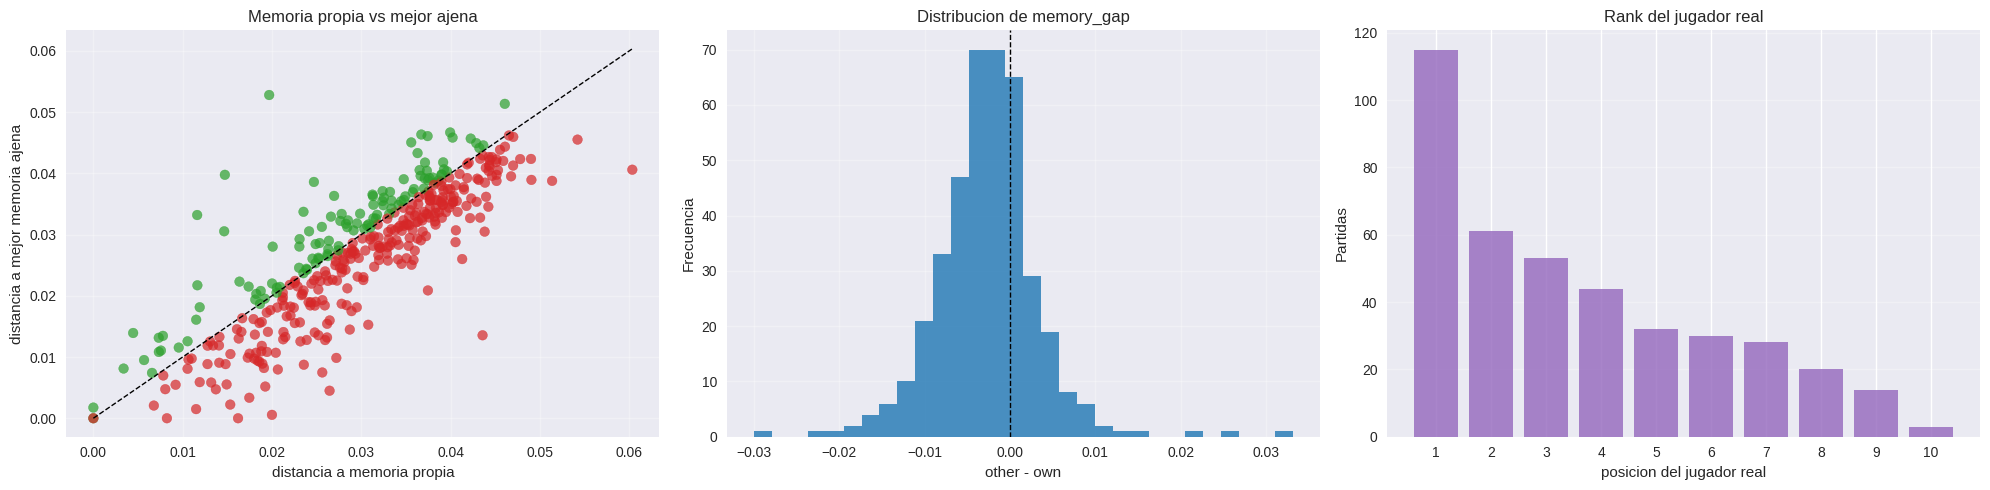

In [ ]:
nearest_same_game_dist = np.full(len(hold_labels), np.inf, dtype=np.float32)
nearest_other_game_dist = np.full(len(hold_labels), np.inf, dtype=np.float32)

for class_idx in range(len(reference_players)):
    query_mask = hold_labels == class_idx
    if not np.any(query_mask):
        continue

    same_mask = train_labels == class_idx
    other_mask = ~same_mask

    same_block = query_to_ref_dists[query_mask][:, same_mask]
    other_block = query_to_ref_dists[query_mask][:, other_mask]

    nearest_same_game_dist[query_mask] = same_block.min(axis=1)
    nearest_other_game_dist[query_mask] = other_block.min(axis=1)

exemplar_gap = nearest_other_game_dist - nearest_same_game_dist

method_analysis_frames = []
method_summary_rows = []
quantile_rows = []

for method_key, method_output in player_method_outputs.items():
    sorted_player_idx = method_output["sorted_idx"]
    analysis_rows = []
    for hold_idx, sample in enumerate(HOLDOUT_SAMPLES):
        true_idx = int(hold_labels[hold_idx])
        pred_idx = int(method_output["pred"][hold_idx])
        ref_order = np.argsort(query_to_ref_dists[hold_idx])[: min(3, len(TRAIN_SAMPLES))]
        support_refs = ", ".join(
            f"{TRAIN_SAMPLES[ref_idx].player}:{TRAIN_SAMPLES[ref_idx].game_id}:{query_to_ref_dists[hold_idx, ref_idx]:.4f}"
            for ref_idx in ref_order
        )
        player_order = sorted_player_idx[hold_idx][: min(3, len(reference_players))]
        top3_players = ", ".join(reference_players[idx] for idx in player_order)
        analysis_rows.append(
            {
                "method_key": method_key,
                "method": method_output["method"],
                "query_index": hold_idx,
                "true_player": sample.player,
                "true_game_id": sample.game_id,
                "pred_player": reference_players[pred_idx],
                "is_correct": bool(pred_idx == true_idx),
                "true_player_rank": int(method_output["true_rank"][hold_idx]),
                "top3_contains_true": bool(method_output["top3_contains_true"][hold_idx]),
                "top5_contains_true": bool(method_output["top5_contains_true"][hold_idx]),
                "own_exemplar_dist": float(nearest_same_game_dist[hold_idx]),
                "other_exemplar_dist": float(nearest_other_game_dist[hold_idx]),
                "exemplar_gap": float(exemplar_gap[hold_idx]),
                "own_memory_dist": float(method_output["own_memory_dist"][hold_idx]),
                "other_memory_dist": float(method_output["other_memory_dist"][hold_idx]),
                "memory_gap": float(method_output["memory_gap"][hold_idx]),
                "top1_margin": float(method_output["top1_margin"][hold_idx]),
                "nearest_ref_player": TRAIN_SAMPLES[nearest_ref_idx[hold_idx]].player,
                "nearest_ref_game_id": TRAIN_SAMPLES[nearest_ref_idx[hold_idx]].game_id,
                "nearest_ref_dist": float(query_to_ref_dists[hold_idx, nearest_ref_idx[hold_idx]]),
                "top3_pred_players": top3_players,
                "top3_support_refs": support_refs,
            }
        )

    method_df = pd.DataFrame(analysis_rows)
    method_analysis_frames.append(method_df)

    method_summary_rows.append(
        {
            "method_key": method_key,
            "method": method_output["method"],
            "is_primary": bool(method_key == PRIMARY_METHOD_KEY),
            "top1_acc": float(method_output["top1"]),
            "top3_acc": float(method_output["top3"]),
            "top5_acc": float(method_output["top5"]),
            "positive_memory_gap": float(np.mean(method_df["memory_gap"] > 0)),
            "mean_memory_gap": float(method_df["memory_gap"].mean()),
            "median_memory_gap": float(method_df["memory_gap"].median()),
            "positive_exemplar_gap": float(np.mean(method_df["exemplar_gap"] > 0)),
            "mean_exemplar_gap": float(method_df["exemplar_gap"].mean()),
            "median_exemplar_gap": float(method_df["exemplar_gap"].median()),
            "mean_true_rank": float(method_df["true_player_rank"].mean()),
            "median_true_rank": float(method_df["true_player_rank"].median()),
            "mean_top1_margin": float(method_df["top1_margin"].mean()),
        }
    )

    for quantile_name, quantile_value in zip(
        ["p10", "p25", "p50", "p75", "p90"],
        [0.10, 0.25, 0.50, 0.75, 0.90],
    ):
        quantile_rows.append(
            {
                "method_key": method_key,
                "method": method_output["method"],
                "quantile": quantile_name,
                "memory_gap": float(np.quantile(method_df["memory_gap"], quantile_value)),
                "exemplar_gap": float(np.quantile(method_df["exemplar_gap"], quantile_value)),
                "top1_margin": float(
                    np.quantile(
                        np.nan_to_num(method_df["top1_margin"], nan=0.0),
                        quantile_value,
                    )
                ),
            }
        )

method_analysis_df = pd.concat(method_analysis_frames, ignore_index=True)
holdout_method_summary_df = (
    pd.DataFrame(method_summary_rows)
    .sort_values(["top1_acc", "mean_memory_gap", "method"], ascending=[False, False, True])
    .reset_index(drop=True)
)
quantile_by_method_df = pd.DataFrame(quantile_rows)

holdout_analysis_df = (
    method_analysis_df.loc[method_analysis_df["method_key"] == PRIMARY_METHOD_KEY]
    .reset_index(drop=True)
)

per_player_method_study_df = (
    method_analysis_df.groupby(["method_key", "method", "true_player"], as_index=False)
    .agg(
        support=("true_game_id", "count"),
        top1_acc=("is_correct", "mean"),
        top3_acc=("top3_contains_true", "mean"),
        top5_acc=("top5_contains_true", "mean"),
        mean_memory_gap=("memory_gap", "mean"),
        median_memory_gap=("memory_gap", "median"),
        positive_memory_gap=("memory_gap", lambda s: float(np.mean(s > 0))),
        mean_exemplar_gap=("exemplar_gap", "mean"),
        median_exemplar_gap=("exemplar_gap", "median"),
        positive_exemplar_gap=("exemplar_gap", lambda s: float(np.mean(s > 0))),
        mean_true_rank=("true_player_rank", "mean"),
        median_true_rank=("true_player_rank", "median"),
        mean_top1_margin=("top1_margin", "mean"),
    )
    .sort_values(
        ["method", "mean_memory_gap", "top1_acc", "true_player"],
        ascending=[True, False, False, True],
    )
    .reset_index(drop=True)
)

hard_failures_by_method_df = (
    method_analysis_df.loc[~method_analysis_df["is_correct"]]
    .sort_values(["method", "memory_gap", "true_player_rank", "top1_margin"], ascending=[True, True, False, True])
    .groupby("method", group_keys=False)
    .head(15)
    .reset_index(drop=True)
)

strong_hits_by_method_df = (
    method_analysis_df.loc[method_analysis_df["is_correct"]]
    .sort_values(["method", "memory_gap", "top1_margin"], ascending=[True, False, False])
    .groupby("method", group_keys=False)
    .head(15)
    .reset_index(drop=True)
)

per_player_study_df = (
    per_player_method_study_df.loc[
        per_player_method_study_df["method_key"] == PRIMARY_METHOD_KEY
    ]
    .reset_index(drop=True)
)
hard_failures_df = (
    hard_failures_by_method_df.loc[
        hard_failures_by_method_df["method_key"] == PRIMARY_METHOD_KEY
    ]
    .reset_index(drop=True)
)
strong_hits_df = (
    strong_hits_by_method_df.loc[
        strong_hits_by_method_df["method_key"] == PRIMARY_METHOD_KEY
    ]
    .reset_index(drop=True)
)
quantile_df = (
    quantile_by_method_df.loc[quantile_by_method_df["method_key"] == PRIMARY_METHOD_KEY]
    .reset_index(drop=True)
)

own_player_memory_dist = holdout_analysis_df["own_memory_dist"].to_numpy(dtype=np.float32)
nearest_other_player_memory_dist = holdout_analysis_df["other_memory_dist"].to_numpy(dtype=np.float32)
memory_gap = holdout_analysis_df["memory_gap"].to_numpy(dtype=np.float32)
true_player_rank = holdout_analysis_df["true_player_rank"].to_numpy(dtype=np.int32)
top1_margin = holdout_analysis_df["top1_margin"].to_numpy(dtype=np.float32)

summary_rows = [
    {"metric": f"Top-1 player-memory ({PRIMARY_METHOD_LABEL})", "value": float(memory_top1), "fmt": "pct"},
    {"metric": f"Top-3 player-memory ({PRIMARY_METHOD_LABEL})", "value": float(memory_top3), "fmt": "pct"},
    {"metric": f"Top-5 player-memory ({PRIMARY_METHOD_LABEL})", "value": float(memory_top5), "fmt": "pct"},
    {"metric": "1-NN partida-partida", "value": float(nn_acc), "fmt": "pct"},
    {"metric": "Hit@1 exemplar", "value": float(hit_at1), "fmt": "pct"},
    {"metric": "Hit@3 exemplar", "value": float(hit_at3), "fmt": "pct"},
    {"metric": "Hit@5 exemplar", "value": float(hit_at5), "fmt": "pct"},
    {"metric": "% memory_gap > 0", "value": float(np.mean(memory_gap > 0)), "fmt": "pct"},
    {"metric": "% exemplar_gap > 0", "value": float(np.mean(exemplar_gap > 0)), "fmt": "pct"},
    {"metric": "Memory gap medio", "value": float(np.mean(memory_gap)), "fmt": "float"},
    {"metric": "Memory gap mediano", "value": float(np.median(memory_gap)), "fmt": "float"},
    {"metric": "Exemplar gap medio", "value": float(np.mean(exemplar_gap)), "fmt": "float"},
    {"metric": "Exemplar gap mediano", "value": float(np.median(exemplar_gap)), "fmt": "float"},
    {"metric": "Rank medio del jugador real", "value": float(np.mean(true_player_rank)), "fmt": "float"},
    {"metric": "Rank mediano del jugador real", "value": float(np.median(true_player_rank)), "fmt": "float"},
    {"metric": "Top-1 margin medio", "value": float(np.nanmean(top1_margin)), "fmt": "float"},
]
summary_df = pd.DataFrame(summary_rows)
summary_df["value_pretty"] = summary_df.apply(
    lambda row: f"{row['value']:.2%}" if row["fmt"] == "pct" else f"{row['value']:.6f}",
    axis=1,
)

quantile_df = pd.DataFrame(
    {
        "memory_gap": np.quantile(memory_gap, [0.10, 0.25, 0.50, 0.75, 0.90]),
        "exemplar_gap": np.quantile(exemplar_gap, [0.10, 0.25, 0.50, 0.75, 0.90]),
        "top1_margin": np.quantile(np.nan_to_num(top1_margin, nan=0.0), [0.10, 0.25, 0.50, 0.75, 0.90]),
    },
    index=["p10", "p25", "p50", "p75", "p90"],
).reset_index(names="quantile")

per_player_study_df = (
    holdout_analysis_df.groupby("true_player", as_index=False)
    .agg(
        support=("true_game_id", "count"),
        top1_acc=("is_correct", "mean"),
        top3_acc=("top3_contains_true", "mean"),
        top5_acc=("top5_contains_true", "mean"),
        mean_memory_gap=("memory_gap", "mean"),
        median_memory_gap=("memory_gap", "median"),
        positive_memory_gap=("memory_gap", lambda s: float(np.mean(s > 0))),
        mean_exemplar_gap=("exemplar_gap", "mean"),
        median_exemplar_gap=("exemplar_gap", "median"),
        positive_exemplar_gap=("exemplar_gap", lambda s: float(np.mean(s > 0))),
        mean_true_rank=("true_player_rank", "mean"),
        median_true_rank=("true_player_rank", "median"),
        mean_top1_margin=("top1_margin", "mean"),
    )
    .sort_values(["mean_memory_gap", "top1_acc", "true_player"], ascending=[False, False, True])
    .reset_index(drop=True)
)

hard_failures_df = (
    holdout_analysis_df.loc[~holdout_analysis_df["is_correct"]]
    .sort_values(["memory_gap", "true_player_rank", "top1_margin"], ascending=[True, False, True])
    .head(15)
    .reset_index(drop=True)
)

strong_hits_df = (
    holdout_analysis_df.loc[holdout_analysis_df["is_correct"]]
    .sort_values(["memory_gap", "top1_margin"], ascending=[False, False])
    .head(15)
    .reset_index(drop=True)
)

print("ESTUDIO DE SEPARABILIDAD · HOLD-OUT")
print("=" * 80)
print("Interpretacion:")
print("- `memory_gap = d(mejor ajeno) - d(propio)`: positivo es bueno; negativo implica que gana un jugador incorrecto.")
print("- `exemplar_gap = d(exemplar ajeno mas cercano) - d(exemplar propio mas cercano)`: positivo es bueno; negativo indica solape local.")
print("- `true_player_rank`: posicion del jugador real en el ranking; ideal = 1.")
print(f"- Metodo primario del notebook: {PRIMARY_METHOD_LABEL}")
print("=" * 80)
print(summary_df[["metric", "value_pretty"]].to_string(index=False))
print("=" * 80)

memory_gap_conditional = holdout_analysis_df.groupby(holdout_analysis_df["memory_gap"] > 0).agg(
    support=("is_correct", "count"),
    top1_acc=("is_correct", "mean"),
    mean_true_rank=("true_player_rank", "mean"),
).reset_index().rename(columns={"memory_gap": "memory_gap_positive"})

display(holdout_method_summary_df)
display(quantile_by_method_df)
display(per_player_method_study_df)
display(hard_failures_by_method_df)
display(strong_hits_by_method_df)
display(summary_df[["metric", "value", "value_pretty"]])
display(quantile_df)
display(per_player_study_df)
display(memory_gap_conditional)
display(hard_failures_df)
display(strong_hits_df)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].scatter(
    holdout_analysis_df["own_memory_dist"],
    holdout_analysis_df["other_memory_dist"],
    c=holdout_analysis_df["is_correct"].map({True: "tab:green", False: "tab:red"}),
    alpha=0.70,
)
lo = float(min(holdout_analysis_df["own_memory_dist"].min(), holdout_analysis_df["other_memory_dist"].min()))
hi = float(max(holdout_analysis_df["own_memory_dist"].max(), holdout_analysis_df["other_memory_dist"].max()))
axes[0].plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1)
axes[0].set_title("Memoria propia vs mejor ajena")
axes[0].set_xlabel("distancia a memoria propia")
axes[0].set_ylabel("distancia a mejor memoria ajena")
axes[0].grid(True, alpha=0.3)

axes[1].hist(memory_gap, bins=30, color="tab:blue", alpha=0.80)
axes[1].axvline(0.0, linestyle="--", color="black", linewidth=1)
axes[1].set_title("Distribucion de memory_gap")
axes[1].set_xlabel("other - own")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(True, alpha=0.3)

rank_counts = holdout_analysis_df["true_player_rank"].value_counts().sort_index()
axes[2].bar(rank_counts.index.astype(str), rank_counts.values, color="tab:purple", alpha=0.80)
axes[2].set_title("Rank del jugador real")
axes[2].set_xlabel("posicion del jugador real")
axes[2].set_ylabel("Partidas")
axes[2].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 6) Inferencia para una partida arbitraria

La inferencia devuelve dos vistas complementarias:

1. ranking de jugadores por soporte de partidas cercanas;
2. ranking de partidas concretas que mejor explican la prediccion.

En uso real conviene evaluar ambos lados (`white` y `black`) y quedarte con la hipotesis mas consistente.


In [ ]:
def build_single_game_tensor(
    game: chess.pgn.Game,
    side: str,
    sequence_len: int,
    fullmove_start: int,
    fullmove_end: int,
    image_size: Tuple[int, int],
) -> Tuple[np.ndarray, np.ndarray]:
    side = side.lower().strip()
    if side not in {"white", "black"}:
        raise ValueError("side debe ser 'white' o 'black'.")

    player_color = chess.WHITE if side == "white" else chess.BLACK
    moves = list(game.mainline_moves())
    selected_halfmoves = select_player_halfmoves(
        total_halfmoves=len(moves),
        player_color=player_color,
        fullmove_start=fullmove_start,
        fullmove_end=fullmove_end,
    )
    if len(selected_halfmoves) < sequence_len:
        raise RuntimeError(
            "La partida no tiene suficientes jugadas para esta configuracion."
        )

    selected_halfmoves = selected_halfmoves[:sequence_len]
    decision_map = extract_decision_seconds_by_halfmove(game)

    board = game.board()
    board_states = {}
    for hm, move in enumerate(moves, start=1):
        board.push(move)
        if hm in selected_halfmoves:
            board_states[hm] = board.copy()
        if len(board_states) == len(selected_halfmoves):
            break

    boards = np.zeros(
        (1, sequence_len, image_size[0], image_size[1], 3), dtype=np.float32
    )
    heats = np.zeros(
        (1, sequence_len, image_size[0], image_size[1], 1), dtype=np.float32
    )

    expected_color_name = "white" if player_color == chess.WHITE else "black"
    for idx, hm in enumerate(selected_halfmoves):
        state = normalize_board_for_player(board_states[hm], player_color)
        rgb = board_to_rgb_array(state, size=400)
        rgb = cv2.resize(
            rgb, (image_size[1], image_size[0]), interpolation=cv2.INTER_AREA
        )
        boards[0, idx] = rgb.astype(np.float32) / 255.0

        move = moves[hm - 1]
        info = decision_map.get(hm, {})
        seconds = (
            float(info.get("seconds", 0.0))
            if info.get("color") == expected_color_name
            else 0.0
        )
        heat = build_player_move_heatmap(
            move,
            seconds,
            image_size[0],
            mirror_for_black=(player_color == chess.BLACK),
        )
        heats[0, idx, :, :, 0] = heat.astype(np.float32) / 255.0

    return boards, heats


def _load_game_from_pgn(pgn_path: Path, game_index: int) -> chess.pgn.Game:
    if not pgn_path.exists():
        raise FileNotFoundError(f"No existe {pgn_path}")
    if pgn_path.is_dir():
        raise ValueError("pgn_path debe ser un archivo .pgn, no un directorio.")

    with open(pgn_path, "r", encoding="utf-8", errors="replace") as f:
        game = None
        for _ in range(game_index):
            game = chess.pgn.read_game(f)
            if game is None:
                raise RuntimeError(f"No existe game_index={game_index} en {pgn_path}")
    return game


def _embed_game_from_pgn(
    pgn_path: Path,
    game_index: int,
    side: str,
) -> np.ndarray:
    game = _load_game_from_pgn(pgn_path, game_index)
    boards, heats = build_single_game_tensor(
        game=game,
        side=side,
        sequence_len=CONFIG.sequence_len,
        fullmove_start=CONFIG.fullmove_start,
        fullmove_end=CONFIG.fullmove_end,
        image_size=CONFIG.image_size,
    )
    emb = embedding_model.predict(
        {"board_sequence": boards, "heat_sequence": heats},
        verbose=0,
    )[0]
    return emb.astype(np.float32)


def _compute_player_distances_for_query(
    query_dists: np.ndarray,
    method: str = "config",
) -> tuple[str, str, np.ndarray]:
    method_key = resolve_player_method_key(method)
    spec = PLAYER_METHOD_SPECS[method_key]
    player_dists = aggregate_player_distances(
        query_dists[None, :],
        train_labels,
        num_players=len(reference_players),
        top_k=spec["top_k"],
        strategy=spec["strategy"],
        temperature=CONFIG.softmin_temperature,
    )[0]
    return method_key, spec["label"], player_dists


def predict_player_from_pgn(
    pgn_path: Path,
    game_index: int = 1,
    side: str = "white",
    top_k: int = 5,
    method: str = "config",
) -> pd.DataFrame:
    emb = _embed_game_from_pgn(pgn_path=pgn_path, game_index=game_index, side=side)
    query_dists = pairwise_distance_matrix(emb[None, :], train_embeddings)[0]
    method_key, method_label, player_dists = _compute_player_distances_for_query(
        query_dists,
        method=method,
    )

    order = np.argsort(player_dists)[: max(1, top_k)]
    support_k = max(1, int(CONFIG.support_examples_per_player))

    rows = []
    for rank_idx, idx in enumerate(order, start=1):
        player_mask = train_labels == idx
        player_ref_idx = np.flatnonzero(player_mask)
        player_ref_dists = query_dists[player_ref_idx]
        local_k = min(support_k, len(player_ref_idx))
        local_order = np.argsort(player_ref_dists)[:local_k]
        support_refs = player_ref_idx[local_order]
        support_games = ", ".join(
            f"{TRAIN_SAMPLES[ref_idx].game_id}:{query_dists[ref_idx]:.4f}"
            for ref_idx in support_refs
        )
        rows.append(
            {
                "method_key": method_key,
                "method": method_label,
                "rank": rank_idx,
                "player": reference_players[idx],
                "player_elo": PLAYER_ELO.get(reference_players[idx], np.nan),
                "distance": float(player_dists[idx]),
                "support_games": support_games,
            }
        )

    return pd.DataFrame(rows)


def compare_player_methods_from_pgn(
    pgn_path: Path,
    game_index: int = 1,
    side: str = "white",
    top_k: int = 5,
) -> pd.DataFrame:
    frames = []
    for method_key in PLAYER_METHOD_SPECS:
        frames.append(
            predict_player_from_pgn(
                pgn_path=pgn_path,
                game_index=game_index,
                side=side,
                top_k=top_k,
                method=method_key,
            )
        )
    return pd.concat(frames, ignore_index=True)


def retrieve_similar_games_from_pgn(
    pgn_path: Path,
    game_index: int = 1,
    side: str = "white",
    top_k: int = 10,
) -> pd.DataFrame:
    emb = _embed_game_from_pgn(pgn_path=pgn_path, game_index=game_index, side=side)
    query_dists = pairwise_distance_matrix(emb[None, :], train_embeddings)[0]
    order = np.argsort(query_dists)[: max(1, top_k)]

    rows = []
    for rank_idx, ref_idx in enumerate(order, start=1):
        sample = TRAIN_SAMPLES[ref_idx]
        rows.append(
            {
                "rank": rank_idx,
                "player": sample.player,
                "player_elo": PLAYER_ELO.get(sample.player, np.nan),
                "game_id": sample.game_id,
                "distance": float(query_dists[ref_idx]),
            }
        )
    return pd.DataFrame(rows)


print("Helpers listos: predict_player_from_pgn(..., method=...), compare_player_methods_from_pgn(...) y retrieve_similar_games_from_pgn(...)")


Helpers listos: predict_player_from_pgn(..., method=...), compare_player_methods_from_pgn(...) y retrieve_similar_games_from_pgn(...)


In [ ]:
PGN_TESTS_DIR = OUTPUT_BASE / "pgn_tests"
PGN_TESTS_DIR.mkdir(parents=True, exist_ok=True)


def _count_games_in_pgn_file(pgn_path: Path) -> int:
    count = 0
    with open(pgn_path, "r", encoding="utf-8", errors="replace") as f:
        while True:
            game = chess.pgn.read_game(f)
            if game is None:
                break
            count += 1
    return count



def build_unseen_pgn_tests_catalog(
    selected_players_df: pd.DataFrame,
    output_dir: Path,
    start_game_idx: Optional[int] = None,
    max_games: Optional[int] = None,
    overwrite: bool = False,
) -> pd.DataFrame:
    if start_game_idx is None:
        start_game_idx = int(CONFIG.games_per_player)
    if max_games is None:
        max_games = int(CONFIG.holdout_games_per_player)

    if "player" not in selected_players_df.columns:
        raise RuntimeError("selected_players_df debe contener la columna 'player'.")

    output_dir.mkdir(parents=True, exist_ok=True)

    work_df = selected_players_df.copy()
    if "zst_path" not in work_df.columns or work_df["zst_path"].isna().any():
        work_df["zst_path"] = work_df["player"].map(find_zst_path)

    missing = work_df.loc[work_df["zst_path"].isna(), "player"].tolist()
    if missing:
        raise RuntimeError(f"No se encontro zst_path para: {missing}")

    rows = []
    for _, row in work_df.iterrows():
        player = str(row["player"])
        zst_path = Path(row["zst_path"])
        out_path = output_dir / f"{player}.pgn"

        if overwrite or not out_path.exists():
            pgn_path, count = decompress_player_pgn_slice(
                player_name=player,
                zst_path=str(zst_path),
                output_dir=output_dir,
                start_game_idx=start_game_idx,
                max_games=max_games,
            )
        else:
            pgn_path = out_path
            count = _count_games_in_pgn_file(pgn_path)

        rows.append(
            {
                "player": player,
                "pgn_path": str(Path(pgn_path).resolve()),
                "games": int(count),
                "absolute_game_start": int(start_game_idx + 1),
                "absolute_game_end": int(start_game_idx + count),
                "guaranteed_unseen_vs_train": True,
            }
        )

    return pd.DataFrame(rows).sort_values("player").reset_index(drop=True)



def resolve_player_side_for_pgn(
    pgn_path: Path,
    player_name: str,
    game_index: int = 1,
) -> str:
    game = _load_game_from_pgn(pgn_path, game_index)
    color = resolve_player_color(game, player_name)
    if color is None:
        raise RuntimeError(
            f"La partida game_index={game_index} de {pgn_path} no pertenece a {player_name}."
        )
    return "white" if color == chess.WHITE else "black"


pgn_tests_df = build_unseen_pgn_tests_catalog(
    selected_players_df=selected_players_df,
    output_dir=PGN_TESTS_DIR,
    start_game_idx=CONFIG.games_per_player,
    max_games=CONFIG.holdout_games_per_player,
    overwrite=False,
)

print("Catalogo PGN_TESTS listo.")
print(
    "Cada archivo contiene partidas fuera de train: empieza en el indice absoluto "
    f"{CONFIG.games_per_player + 1}."
)
display(pgn_tests_df)


Catalogo PGN_TESTS listo.
Cada archivo contiene partidas fuera de train: empieza en el indice absoluto 181.


,player,pgn_path,games,absolute_game_start,absolute_game_end,guaranteed_unseen_vs_train
0,Arsibbalt-1991,/workspace/code/labs/notebooks/output/events/c...,40,181,220,True
1,Edssoto,/workspace/code/labs/notebooks/output/events/c...,40,181,220,True
2,Migrant-is,/workspace/code/labs/notebooks/output/events/c...,40,181,220,True
3,RRusso,/workspace/code/labs/notebooks/output/events/c...,40,181,220,True
4,V2ethereum,/workspace/code/labs/notebooks/output/events/c...,40,181,220,True
5,edulol,/workspace/code/labs/notebooks/output/events/c...,40,181,220,True
6,giliazov,/workspace/code/labs/notebooks/output/events/c...,40,181,220,True
7,sabino31,/workspace/code/labs/notebooks/output/events/c...,40,181,220,True
8,shanis34,/workspace/code/labs/notebooks/output/events/c...,40,181,220,True
9,ujjawal305,/workspace/code/labs/notebooks/output/events/c...,40,181,220,True


In [ ]:
preferred_demo_player = "andresuribe"
if preferred_demo_player in set(pgn_tests_df["player"]):
    demo_row = pgn_tests_df.loc[pgn_tests_df["player"] == preferred_demo_player].iloc[0]
else:
    demo_row = pgn_tests_df.iloc[0]

demo_player = str(demo_row["player"])
demo_pgn = Path(demo_row["pgn_path"])
demo_game_index = 1
demo_side = resolve_player_side_for_pgn(
    pgn_path=demo_pgn,
    player_name=demo_player,
    game_index=demo_game_index,
)
demo_absolute_game_index = int(demo_row["absolute_game_start"]) + demo_game_index - 1

print(
    f"Demo unseen -> player={demo_player} | game_index_en_archivo={demo_game_index} "
    f"| game_index_absoluto={demo_absolute_game_index} | side={demo_side}"
)
print(f"PGN source: {demo_pgn}")

player_methods_df = compare_player_methods_from_pgn(
    demo_pgn,
    game_index=demo_game_index,
    side=demo_side,
    top_k=5,
)
matches_df = retrieve_similar_games_from_pgn(
    demo_pgn,
    game_index=demo_game_index,
    side=demo_side,
    top_k=10,
)

display(player_methods_df)
display(matches_df)


,method_key,method,rank,player,player_elo,distance,support_games
0,mean_topk,mean(top-5),1,Edssoto,2280,0.024690,"0146:0.0142, 0090:0.0252, 0042:0.0272"
1,mean_topk,mean(top-5),2,shanis34,1653,0.025922,"0175:0.0222, 0088:0.0236, 0045:0.0269"
2,mean_topk,mean(top-5),3,Migrant-is,1229,0.027886,"0145:0.0269, 0111:0.0271, 0149:0.0283"
3,mean_topk,mean(top-5),4,edulol,1460,0.028276,"0147:0.0240, 0079:0.0285, 0161:0.0293"
4,mean_topk,mean(top-5),5,V2ethereum,1889,0.029302,"0059:0.0256, 0136:0.0291, 0100:0.0302"
5,softmin_topk,softmin(top-5),1,Edssoto,2280,0.023735,"0146:0.0142, 0090:0.0252, 0042:0.0272"
6,softmin_topk,softmin(top-5),2,shanis34,1653,0.025717,"0175:0.0222, 0088:0.0236, 0045:0.0269"
7,softmin_topk,softmin(top-5),3,Migrant-is,1229,0.027871,"0145:0.0269, 0111:0.0271, 0149:0.0283"
8,softmin_topk,softmin(top-5),4,edulol,1460,0.028124,"0147:0.0240, 0079:0.0285, 0161:0.0293"
9,softmin_topk,softmin(top-5),5,V2ethereum,1889,0.029184,"0059:0.0256, 0136:0.0291, 0100:0.0302"


,rank,player,player_elo,game_id,distance
0,1,Edssoto,2280,0146,0.014236
1,2,shanis34,1653,0175,0.022232
2,3,shanis34,1653,0088,0.023645
3,4,edulol,1460,0147,0.023988
4,5,Arsibbalt-1991,1197,0048,0.024623
5,6,Edssoto,2280,0090,0.025150
6,7,ujjawal305,941,0015,0.025571
7,8,V2ethereum,1889,0059,0.025610
8,9,RRusso,1904,0091,0.026149
9,10,shanis34,1653,0045,0.026864


## 7) Recomendaciones para potenciar la memoria estilometrica

1. **Memoria separada por color**: mantener bancos independientes para blancas y negras, o ponderarlos distinto.
2. **Submemorias por fase/tempo**: openings, medio juego, finales, y bins de tiempo de decision.
3. **Mining mas duro**: negativos cercanos por ELO, apertura o control de tiempo para forzar discriminacion fina.
4. **Agregacion adaptativa**: sustituir el `mean(top-k)` por softmin, attention o learned pooling por jugador.
5. **Open-set / rechazo**: umbral sobre margen intra/inter para detectar partidas de jugadores no vistos.
6. **Mapa del jugador**: clusterizar sus partidas y medir si emergen subestilos estables.


## 8) Analisis matematico y referencias

Para embeddings L2-normalizados, la distancia euclidea cumple `d in [0, 2]`.

El entrenamiento sigue optimizando a nivel partida:

- `L_triplet = max(0, d(a,p) - d(a,n) + m)`

La diferencia con el 110 aparece en inferencia. Para una query `q` y el conjunto de partidas `G_j` de un jugador `j`:

- Distancia partida-partida: `d(q, x) = ||e(q) - e(x)||_2`
- Memoria del jugador: `D_j(q) = mean(top_k{ d(q, x) : x in G_j })`
- Variante mas suave: `D_j^soft(q) = sum w_x d(q,x)` con `w_x propto exp(-tau d(q,x))`

La hipotesis estilometrica es:

1. si `q` pertenece al jugador `y`, entonces `D_y(q)` debe ser minima;
2. si `j != y`, entonces `D_j(q)` debe quedar suficientemente separada.

Indicadores utiles:

1. **Top-k player accuracy** sobre `D_j(q)`.
2. **Hit@k exemplar**: al menos una de las `k` partidas mas cercanas pertenece al jugador correcto.
3. **Margen exemplar**: `min_other d(q, x) - min_same d(q, x)`.
4. **Margen player-memory**: `min_{j != y} D_j(q) - D_y(q)`.

Referencias usadas para el rediseño:

- FaceNet (triplet mining): https://arxiv.org/abs/1503.03832
- In Defense of the Triplet Loss (batch-hard): https://arxiv.org/abs/1703.07737
- Sampling Matters in Deep Embedding Learning: https://arxiv.org/abs/1706.07567
- Behavioral Stylometry in Chess (NeurIPS): https://arxiv.org/abs/2208.01366
